# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 11     |  |
| :-------------|:-------------|
| Hugo Rutten | 6541593 |
| Yael Jawahierkhan | 6444504 |
| Matteo Leonardi | 6391494 |

In [2]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['Yael Jawahierkhan','Matteo Leonardi']

## Opdracht 1: Planning.

| Planning Groep: 11     |Tijdstip / Tijdspanne  |
|---|---|
| Kalibreren van de sensor af | 11:30 |
| Testen meetopstelling | 12:00 |
| Algoritme iteratie 0 af | 15:00 |
| Iteraties maken | 16:30 |
| Alles testen en opruimen | 16:30-17:30 |
| groep aanwezig 1| 10:45 |
| Pauze 1| 12:45-13:45 |


## Opdracht 2: Import libs.

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep [11]

<img src="KalibratieOpstelling.jpeg" width="400">

a= 0.03440668755754128
b =  0.3237959096074584


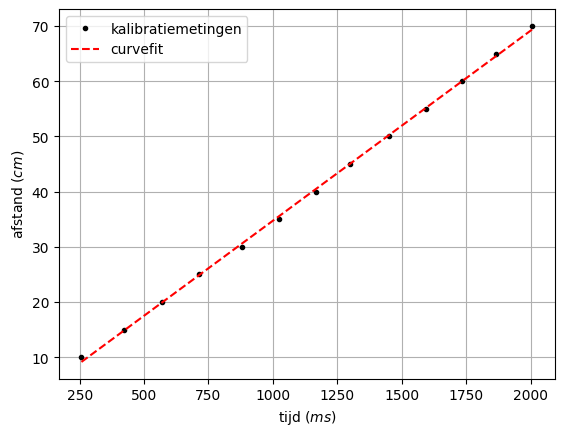

In [4]:
# verwerk hier jullie kalibratiemetingen
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


tijden = np.array([257,424,569,715,881,1023,1167,1301,1450,1595,1735,1867,2007]) #ms
afstanden = np.array([10.0,15.0,20.0, 25.0,30.0,35.0,40.0,45.0,50.0,55.0,60.0,65.0,70.0]) #cm

x_test = np.linspace(np.min(tijden),np.max(tijden))

def fit(x,a,b):
    return a*x+b

val, cov = curve_fit(fit,tijden,afstanden)

print('a=', val[0])
print( 'b = ', val[1])


plt.figure()
plt.plot(tijden,afstanden,'k.',label='kalibratiemetingen')
plt.plot(x_test,fit(x_test,*val),'r--',label='curvefit')
plt.ylabel('afstand $(cm)$')
plt.xlabel('tijd $(ms)$')
plt.grid()
plt.legend()
plt.show()


## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0   0  40   0  30  44.47
1   0  30   0  20  45.52
2  40   0  30   0  47.95
3  30   0  20   0  47.58


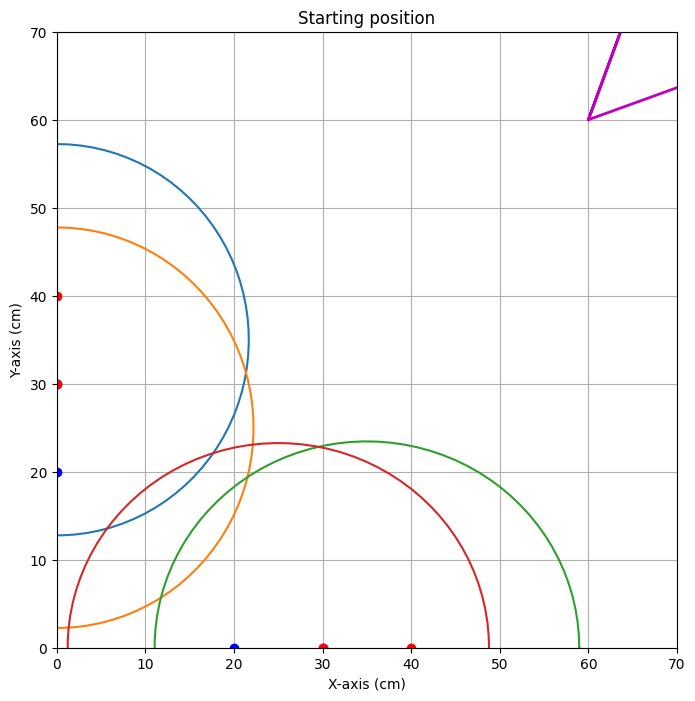


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=95.575


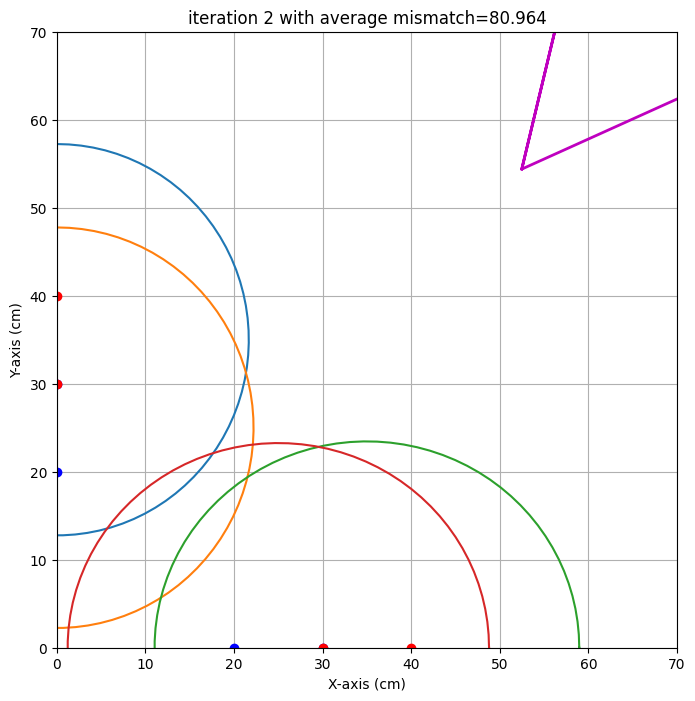

end iteration 2 with average mismatch=80.964


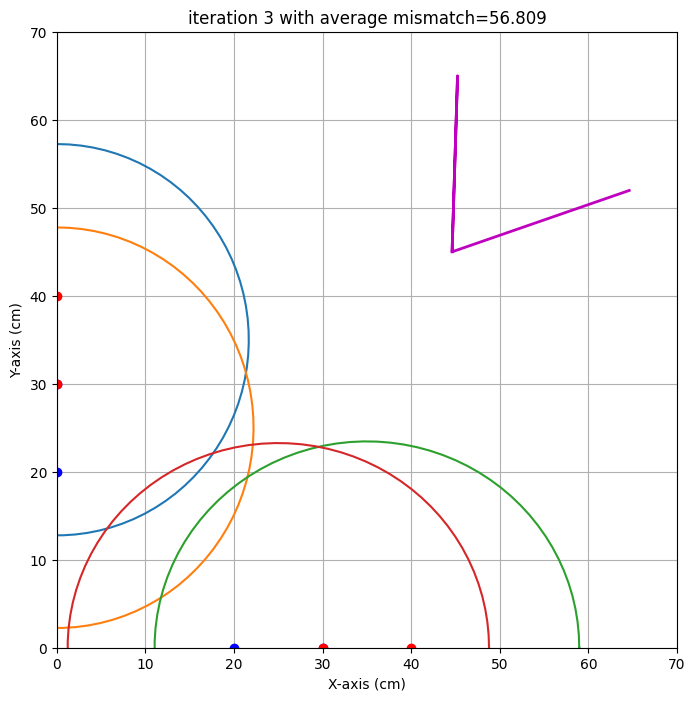

end iteration 3 with average mismatch=56.809


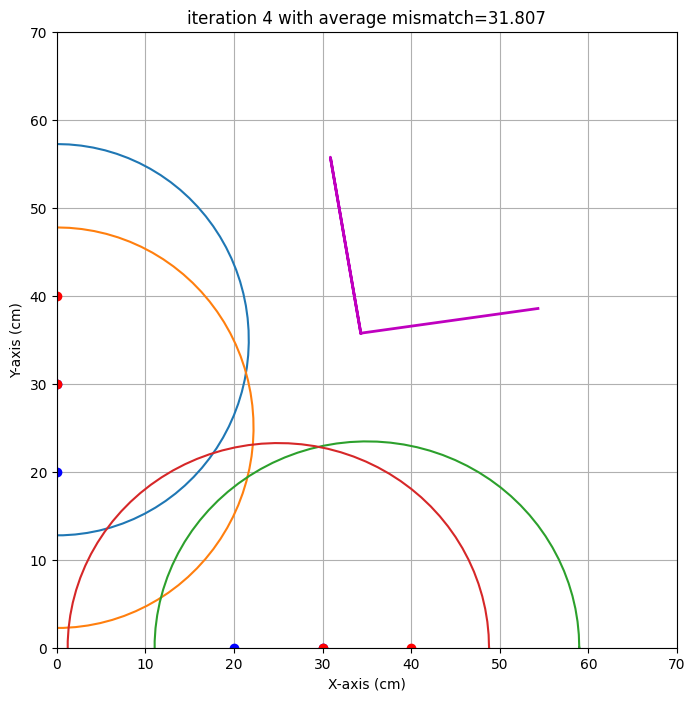

end iteration 4 with average mismatch=31.807


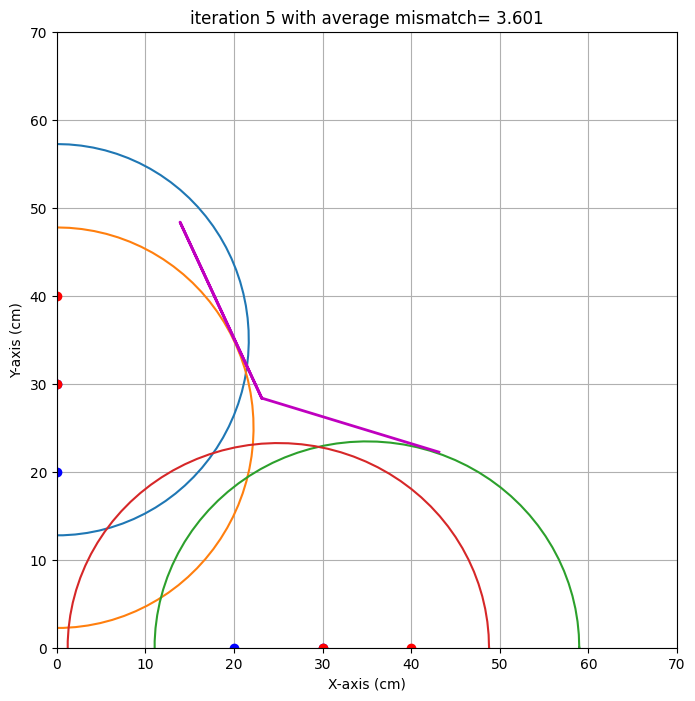

end iteration 5 with average mismatch= 3.601
end iteration 6 with average mismatch= 3.485


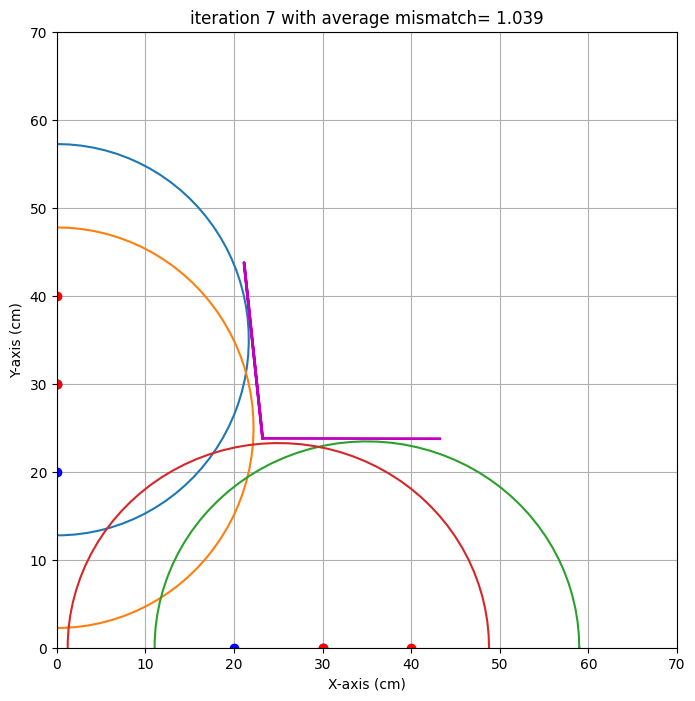

end iteration 7 with average mismatch= 1.039


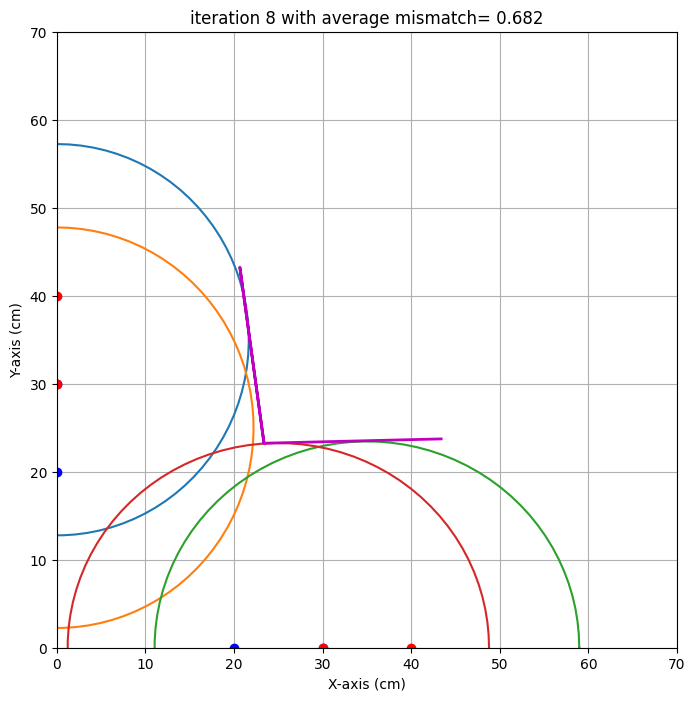

end iteration 8 with average mismatch= 0.682
end iteration 9 with average mismatch= 0.617
end iteration 10 with average mismatch= 0.575
end iteration 11 with average mismatch= 0.555
end iteration 12 with average mismatch= 0.554
end iteration 13 with average mismatch= 0.554
end iteration 14 with average mismatch= 0.553
end iteration 15 with average mismatch= 0.553
end iteration 16 with average mismatch= 0.553
end iteration 17 with average mismatch= 0.553
end iteration 18 with average mismatch= 0.553
end iteration 19 with average mismatch= 0.553
end iteration 20 with average mismatch= 0.553


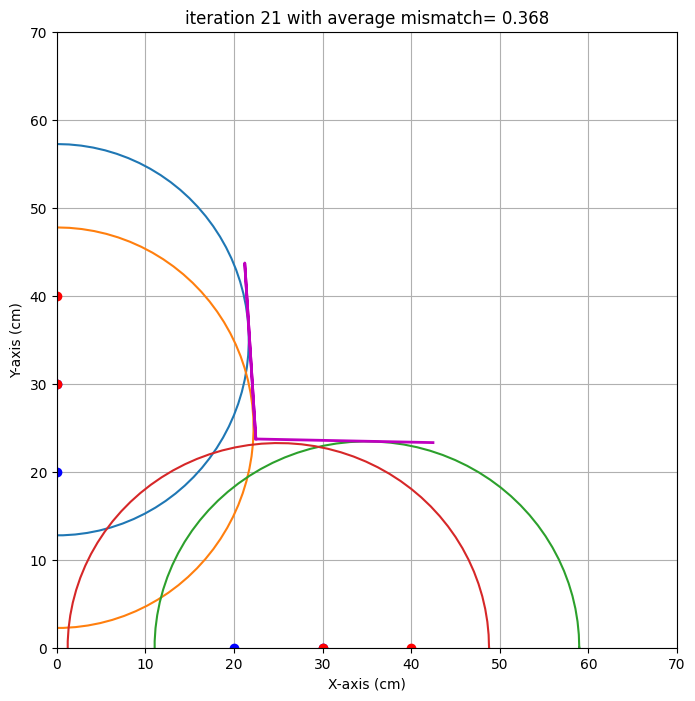

end iteration 21 with average mismatch= 0.368
end iteration 22 with average mismatch= 0.344
end iteration 23 with average mismatch= 0.344
end iteration 24 with average mismatch= 0.344
end iteration 25 with average mismatch= 0.344
end iteration 26 with average mismatch= 0.344


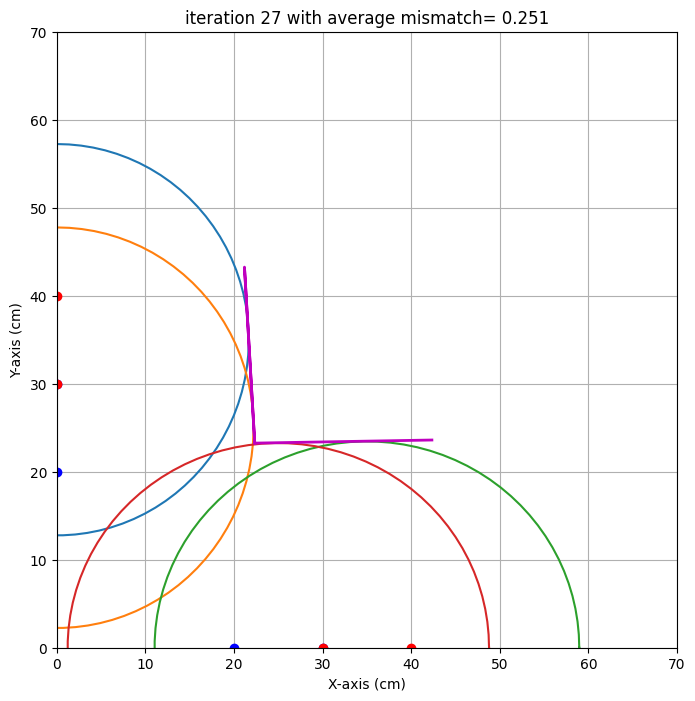

end iteration 27 with average mismatch= 0.251


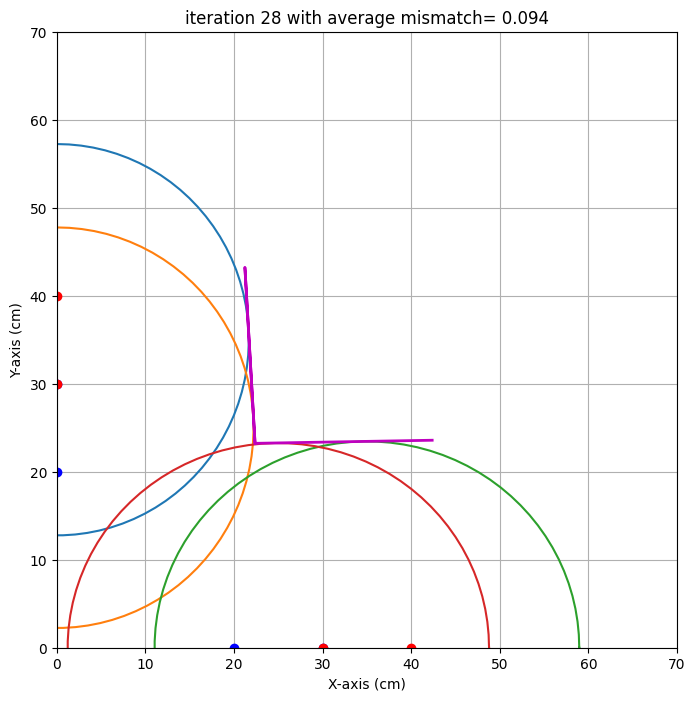

end iteration 28 with average mismatch= 0.094
end iteration 29 with average mismatch= 0.094
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.094
###############################################################################
end of iteration  30
Best alpha=   1.01 with uncertainty=   0.00
Best beta =  -3.27 with uncertainty=   0.00
Best x0   =  22.37 with uncertainty=   0.00
Best y0   =  23.23 with uncertainty=   0.00
###############################################################################
no uncertainty found, please run again


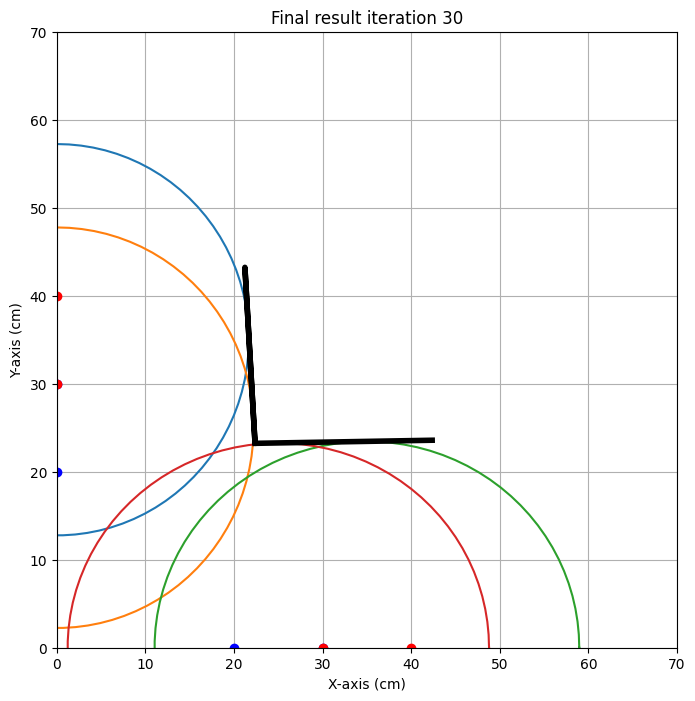

In [5]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

                
dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,44.47],
    [0,30,0,20,45.52],
    #[0,10,0,20,193.37],
    [40,0,30,0,47.95],
    [30,0,20,0,47.58],
    #[10,0,20,0,190.56],
    #[10,0,0,10,191.41]    
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [6]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 22.4 cm met een standaardafwijking van 0.0 cm 
y0: 23.2 cm met een standaardafwijking van 0.0 cm 
alpha: 1.0 graden met een standaardafwijking van 0.0 graad 
beta: -3.3 graden met een standaardafwijking van 0.0 graad 



## Opdracht 5: Iteratie 0

#### algoritme [Hugo Rutten]

Voeg een foto in van het algoritme van het eerste groepslid

<img src="SchemaHugo.jpeg" width="400">

#### algoritme [Yael Jawahierkhan]

Voeg een foto in van het algoritme van het tweede groepslid

<img src="SchemaYael.jpeg" width="400">

#### algoritme [Matteo Leonardi]

Voeg een foto in van het algoritme van het derde groepslid

<img src="SchemaMatteo.jpeg" width="400">

In [7]:
# Voeg hier eventueel code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 6: Test iteratie 0.

In [8]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0': 24,   
           'y0': 31,
           'alpha': 25,  
           'beta': 10,  
          }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={'Yael Jawahierkhan' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
  [62.4,0,52.5,0,83.5],
    [0,62.5,0,52.5,65.2],
    #[0,70,0,60,200],
    #[70,0,60,0,200],

    ]),
       'Matteo Leonardi' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
  [70,0,50,0,87.8],
    [60,0,40,0,79.6],
    [60,0,50,0,81.5],
    [0,70,0,50,67.9],  
    [0,60,0,40,63.6],
    [0,60,0,50,63.2],
    ])}

## Opdracht 7: Evaluatie.

Yael Jawahierkhan
Running the imaging algorithm with the following data:
     xs    ys    xr    yr     R
0  62.4   0.0  52.5   0.0  83.5
1   0.0  62.5   0.0  52.5  65.2


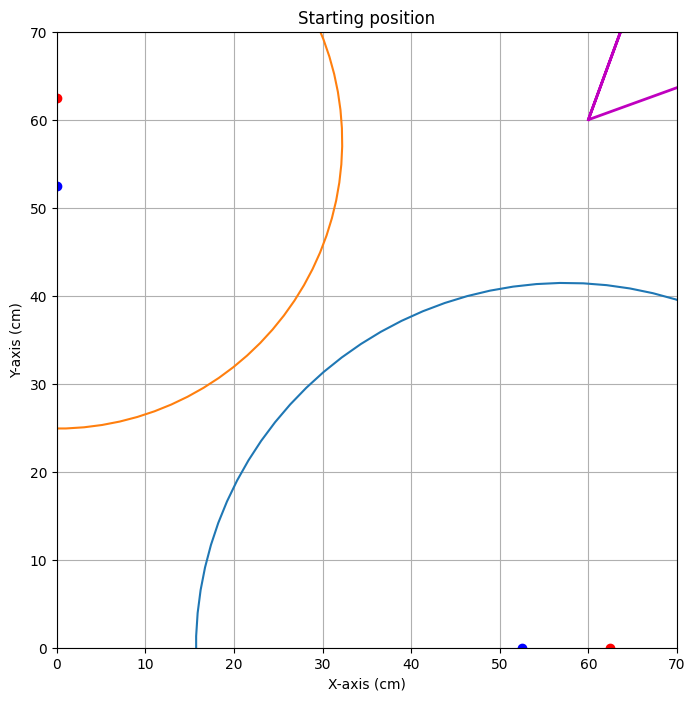


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=51.706


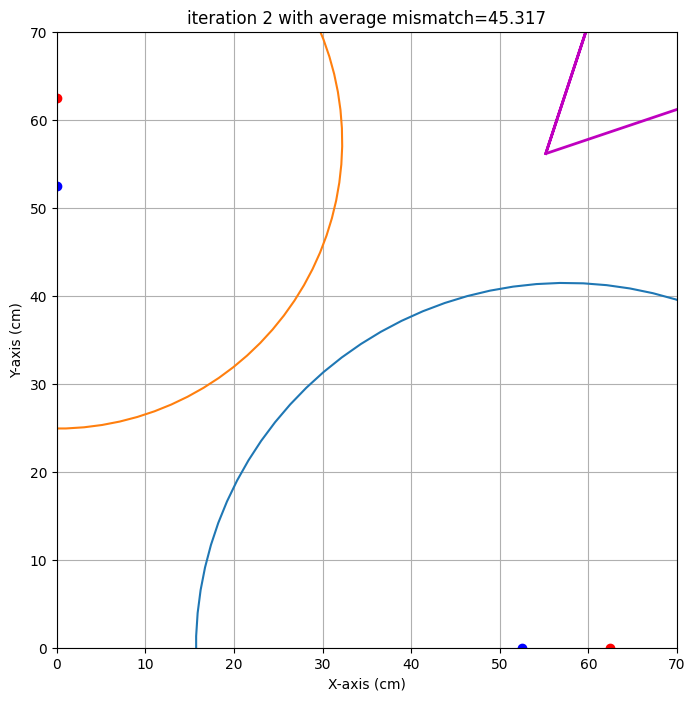

end iteration 2 with average mismatch=45.317


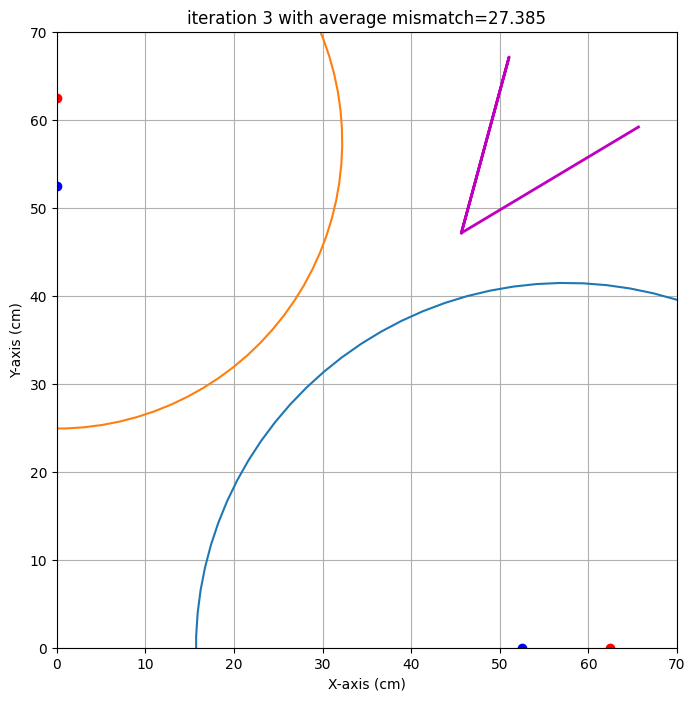

end iteration 3 with average mismatch=27.385


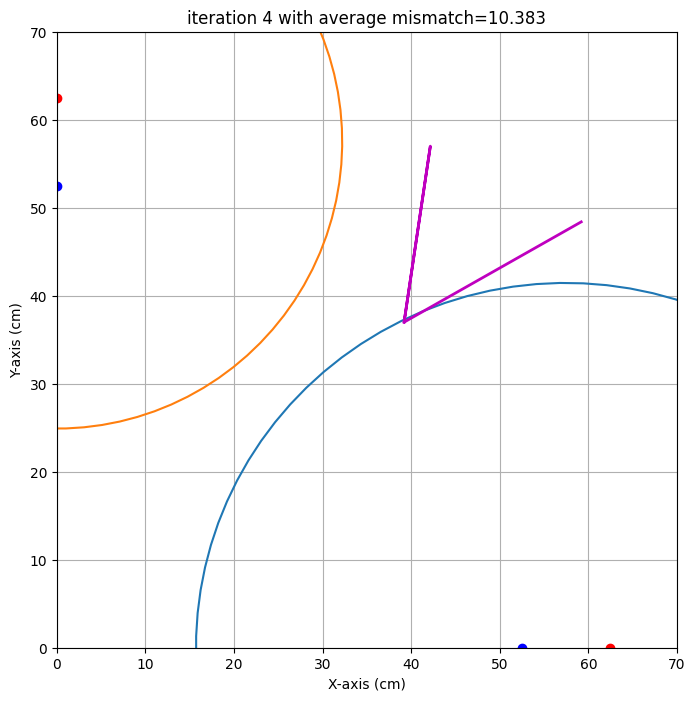

end iteration 4 with average mismatch=10.383


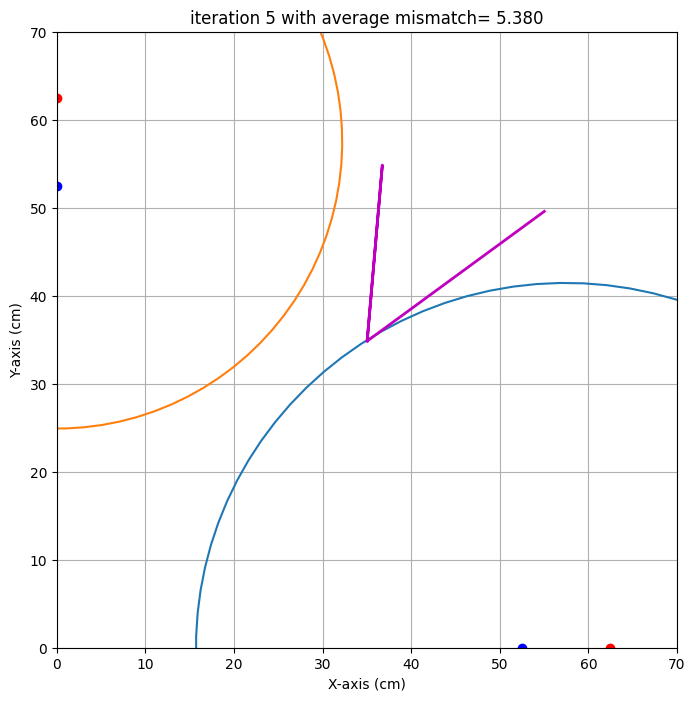

end iteration 5 with average mismatch= 5.380


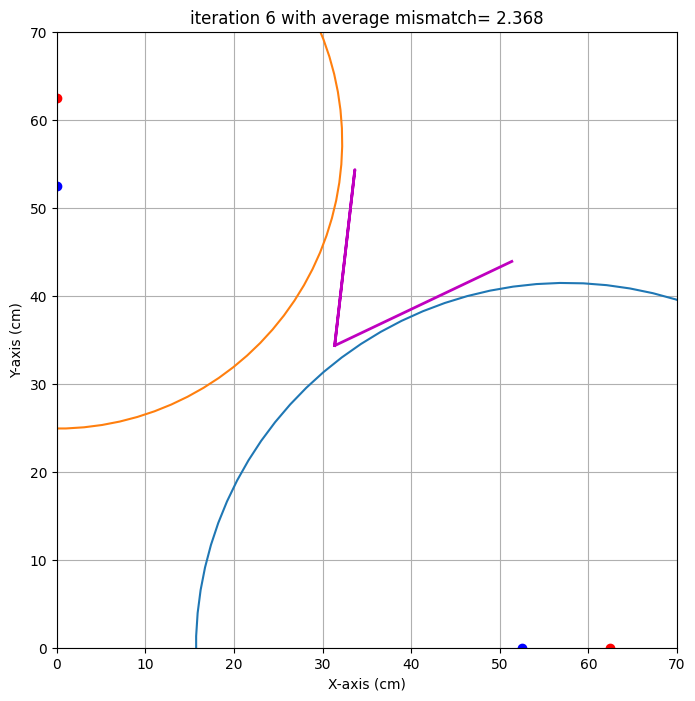

end iteration 6 with average mismatch= 2.368


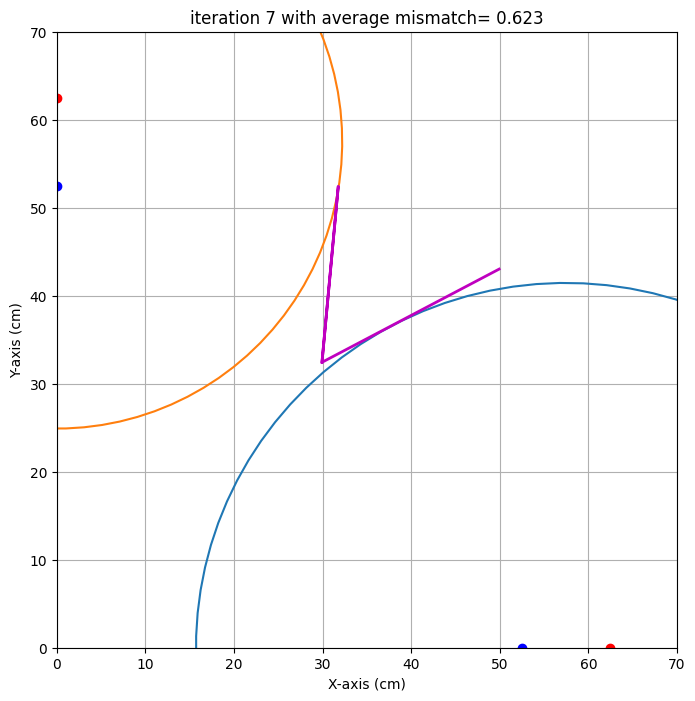

end iteration 7 with average mismatch= 0.623
end iteration 8 with average mismatch= 0.583


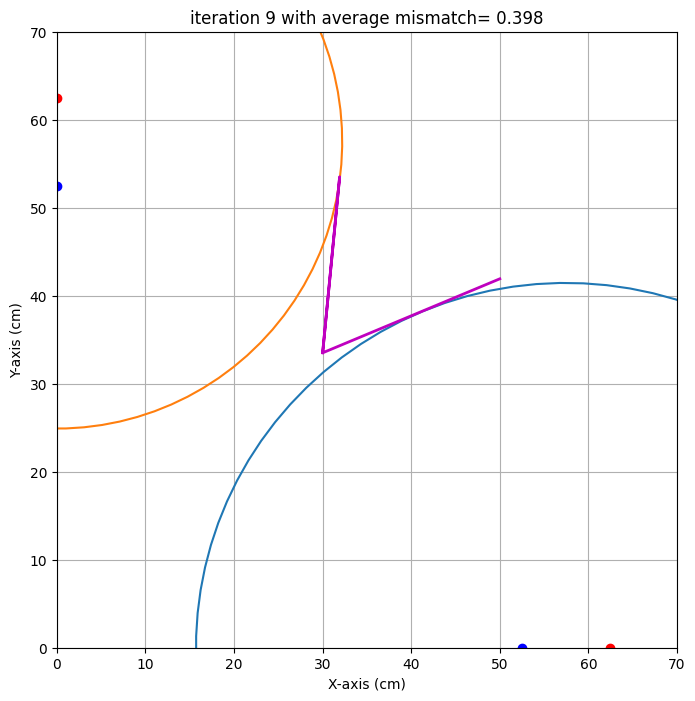

end iteration 9 with average mismatch= 0.398


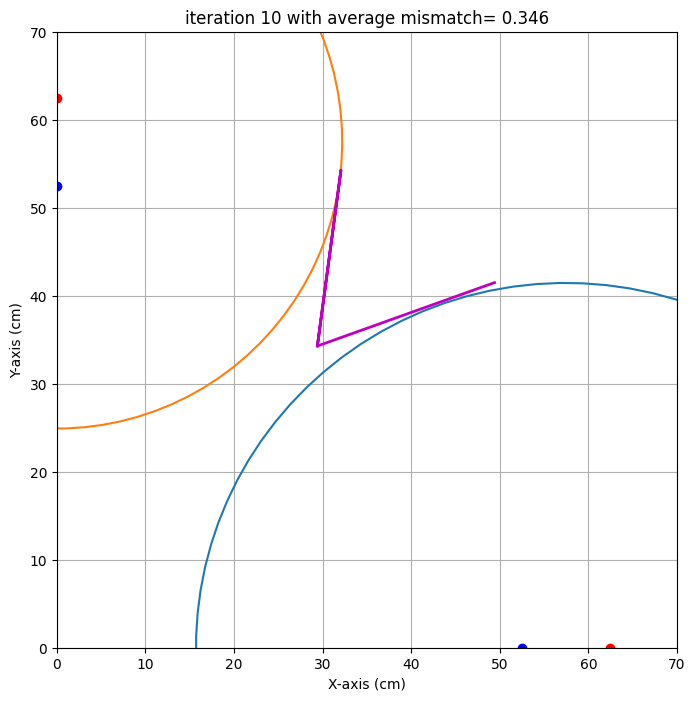

end iteration 10 with average mismatch= 0.346


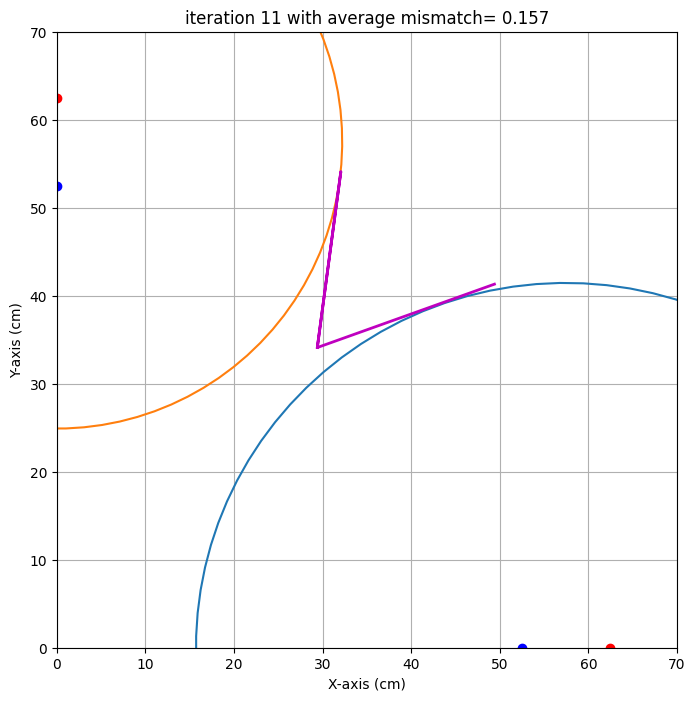

end iteration 11 with average mismatch= 0.157


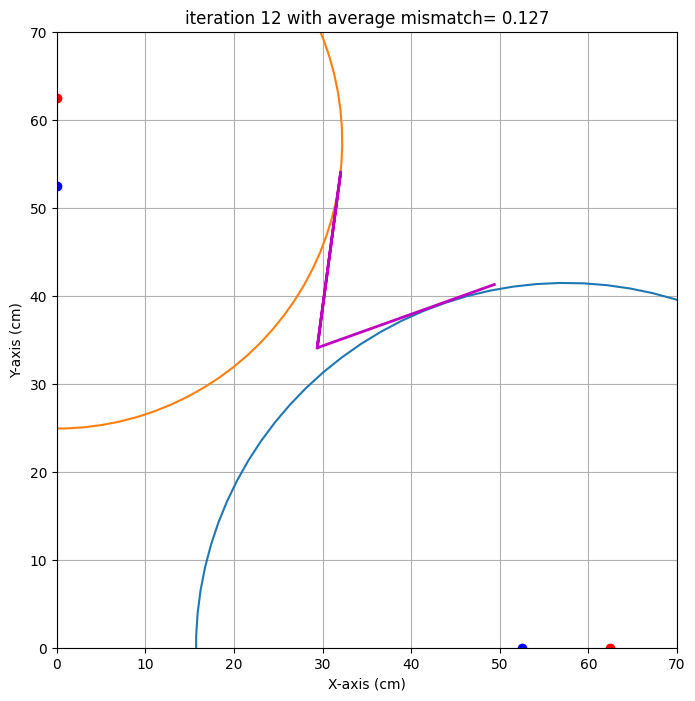

end iteration 12 with average mismatch= 0.127


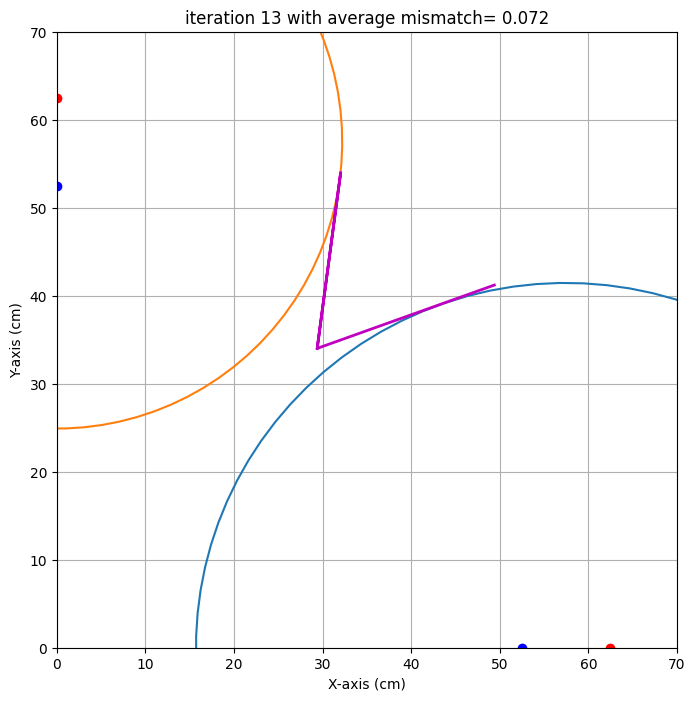

end iteration 13 with average mismatch= 0.072


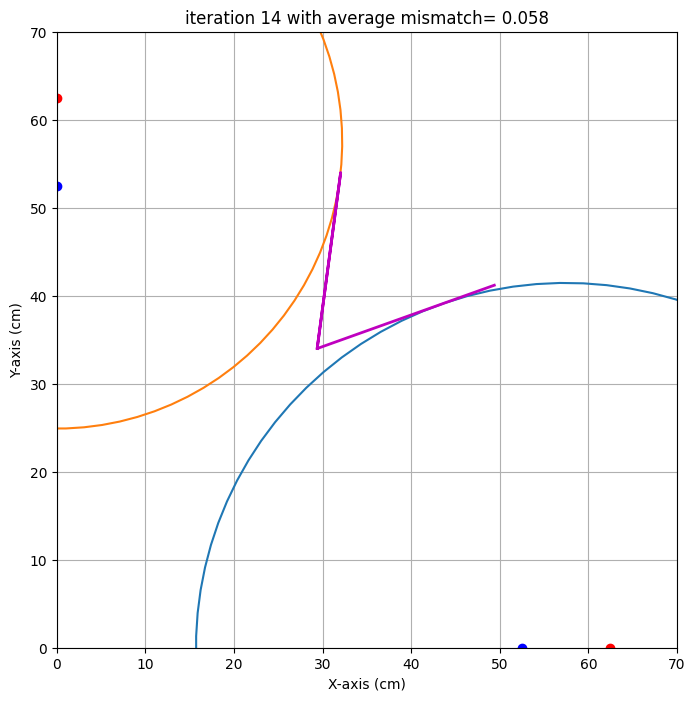

end iteration 14 with average mismatch= 0.058
end iteration 15 with average mismatch= 0.056
end iteration 16 with average mismatch= 0.056
end iteration 17 with average mismatch= 0.056
end iteration 18 with average mismatch= 0.056
end iteration 19 with average mismatch= 0.056
end iteration 20 with average mismatch= 0.056
end iteration 21 with average mismatch= 0.056
end iteration 22 with average mismatch= 0.056
end iteration 23 with average mismatch= 0.056
end iteration 24 with average mismatch= 0.056
end iteration 25 with average mismatch= 0.056
end iteration 26 with average mismatch= 0.056
end iteration 27 with average mismatch= 0.056
end iteration 28 with average mismatch= 0.056
end iteration 29 with average mismatch= 0.056
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.056
###############################################################################
end of iteration  30
Best alp

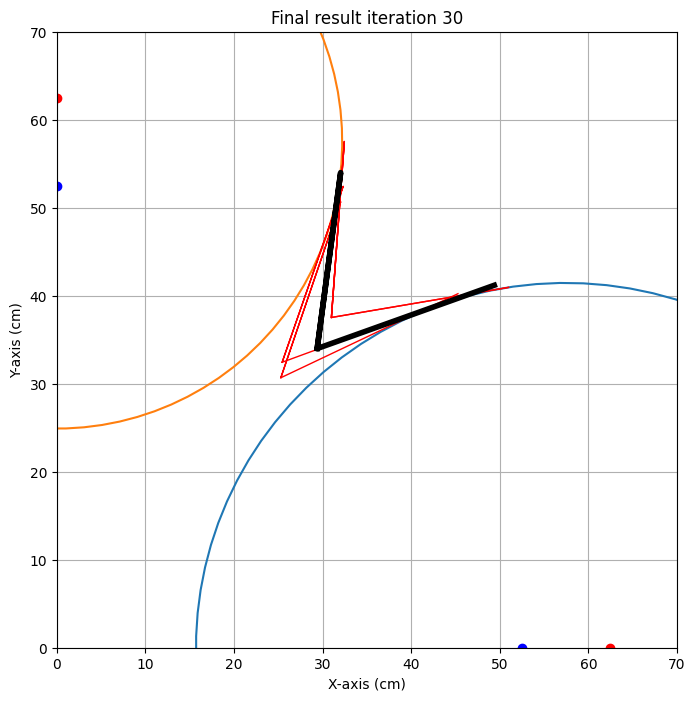

{'alpha': np.float64(19.78634988522522), 'alpha_eps': np.float64(10.082039848891577), 'beta': np.float64(7.560052781720428), 'beta_eps': np.float64(11.465527823481041), 'x0': np.float64(29.38328762865689), 'x0_eps': np.float64(4.101687615576765), 'y0': np.float64(33.99445495773814), 'y0_eps': np.float64(3.5321060112812717)}
Matteo Leonardi
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  70   0  50   0  87.8
1  60   0  40   0  79.6
2  60   0  50   0  81.5
3   0  70   0  50  67.9
4   0  60   0  40  63.6
5   0  60   0  50  63.2


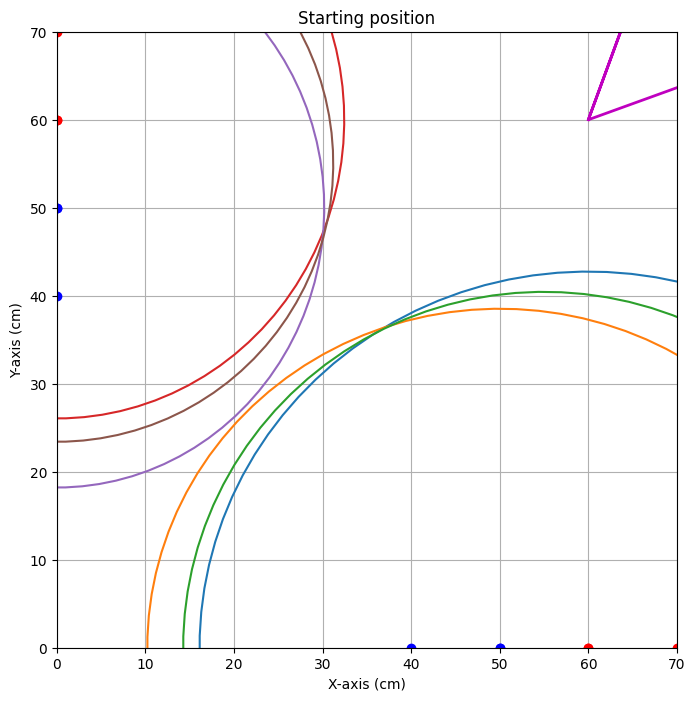


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=53.671


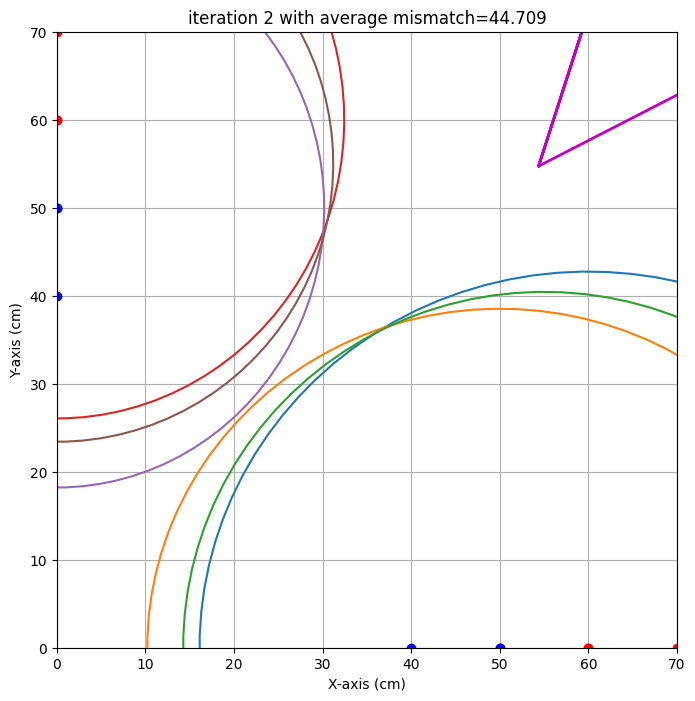

end iteration 2 with average mismatch=44.709


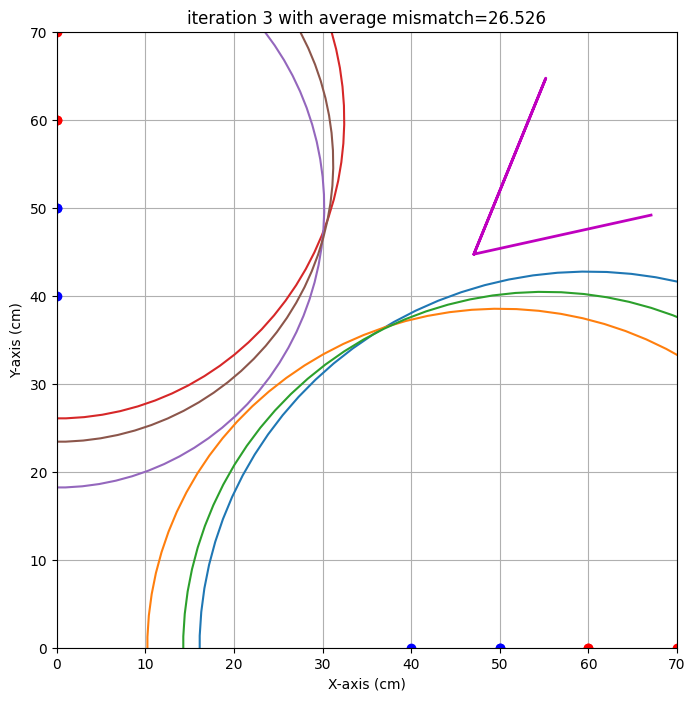

end iteration 3 with average mismatch=26.526


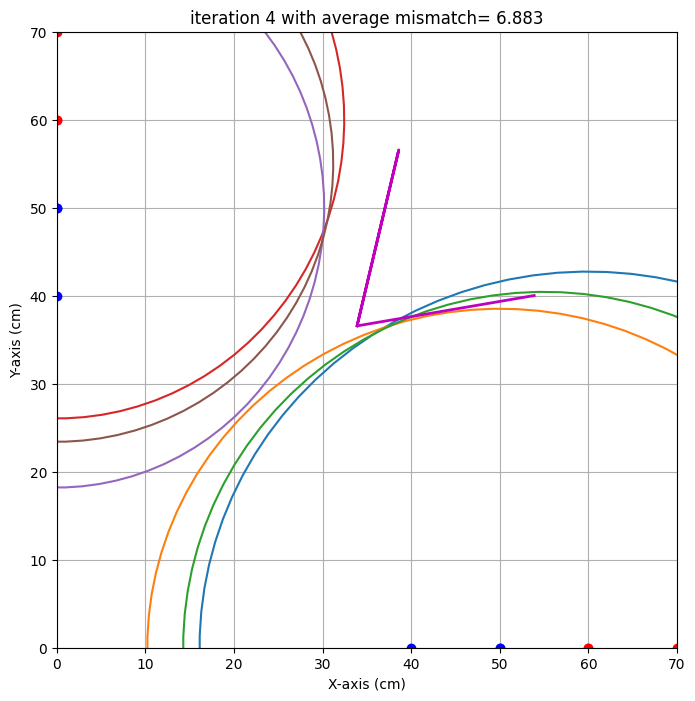

end iteration 4 with average mismatch= 6.883


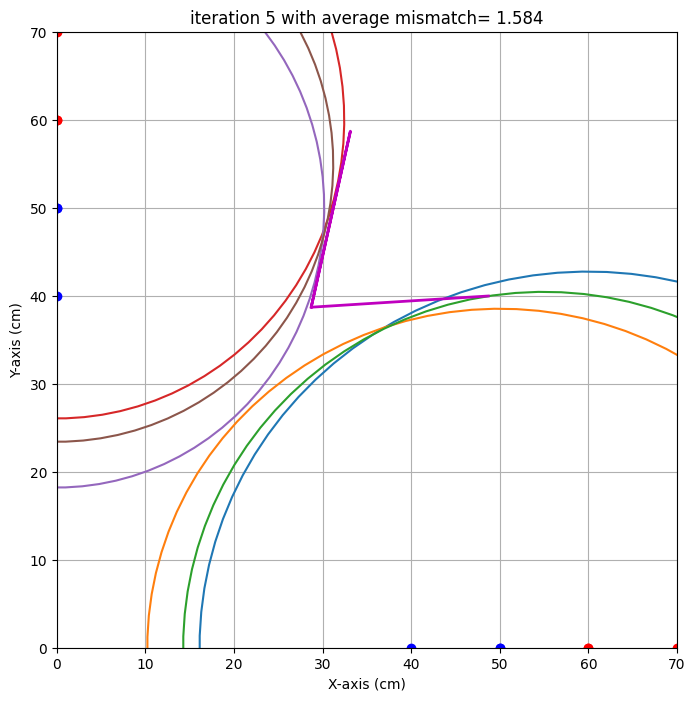

end iteration 5 with average mismatch= 1.584


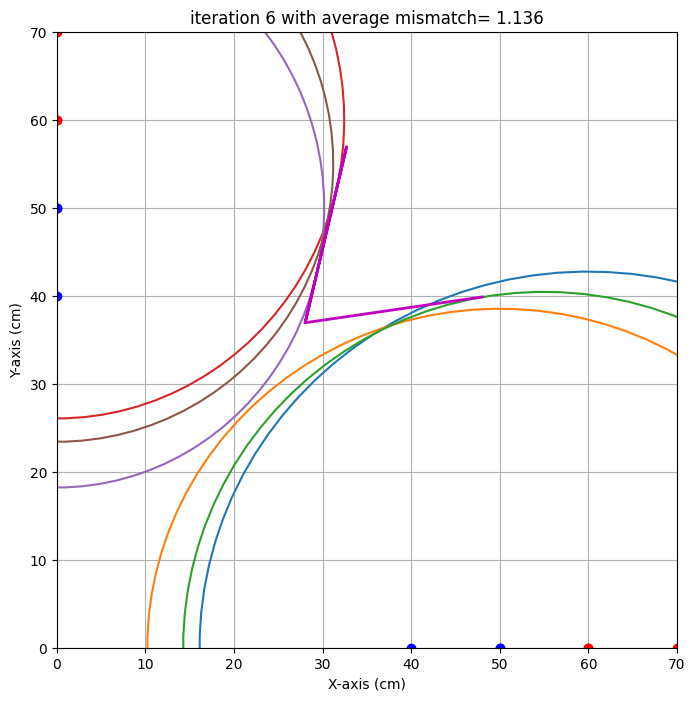

end iteration 6 with average mismatch= 1.136
end iteration 7 with average mismatch= 1.124
end iteration 8 with average mismatch= 1.124
end iteration 9 with average mismatch= 1.124
end iteration 10 with average mismatch= 1.124
end iteration 11 with average mismatch= 1.124
end iteration 12 with average mismatch= 1.124
end iteration 13 with average mismatch= 1.124
end iteration 14 with average mismatch= 1.124
end iteration 15 with average mismatch= 1.053
end iteration 16 with average mismatch= 1.046
end iteration 17 with average mismatch= 1.046
end iteration 18 with average mismatch= 1.046
end iteration 19 with average mismatch= 1.046
end iteration 20 with average mismatch= 1.046
end iteration 21 with average mismatch= 1.009


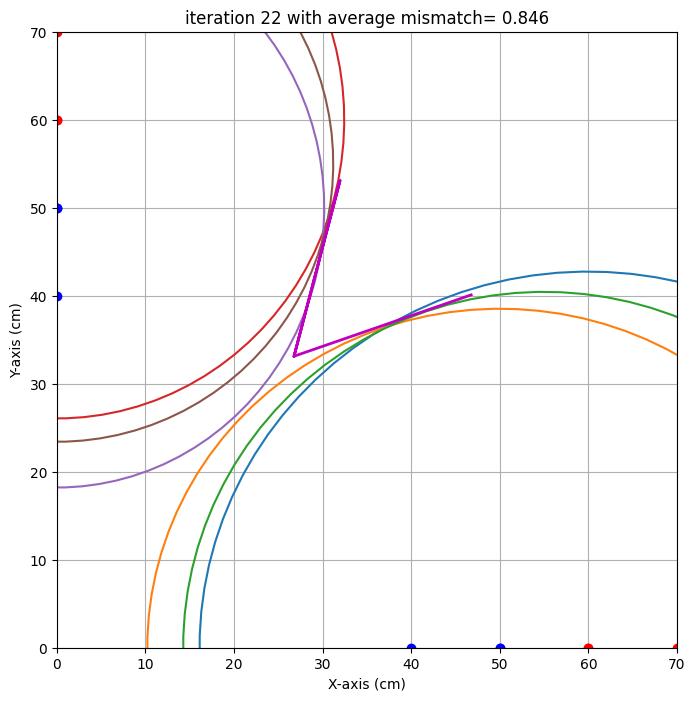

end iteration 22 with average mismatch= 0.846


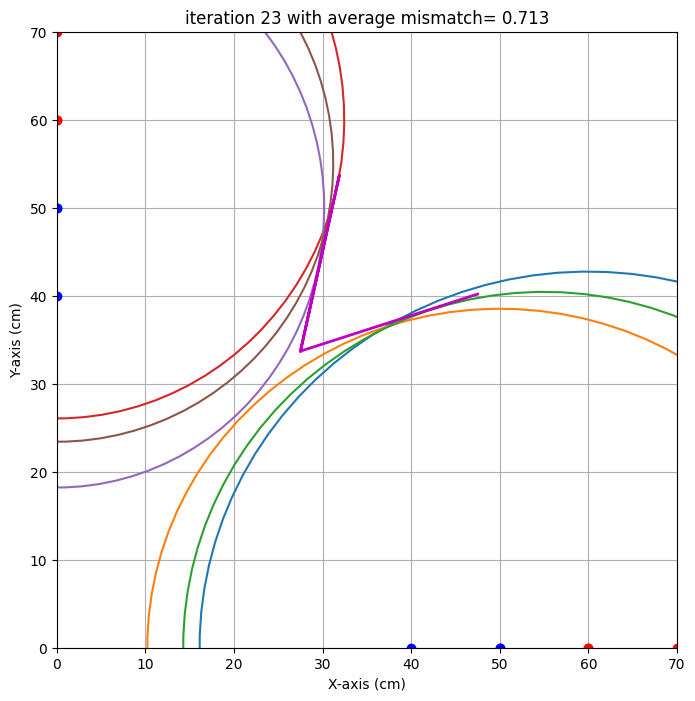

end iteration 23 with average mismatch= 0.713


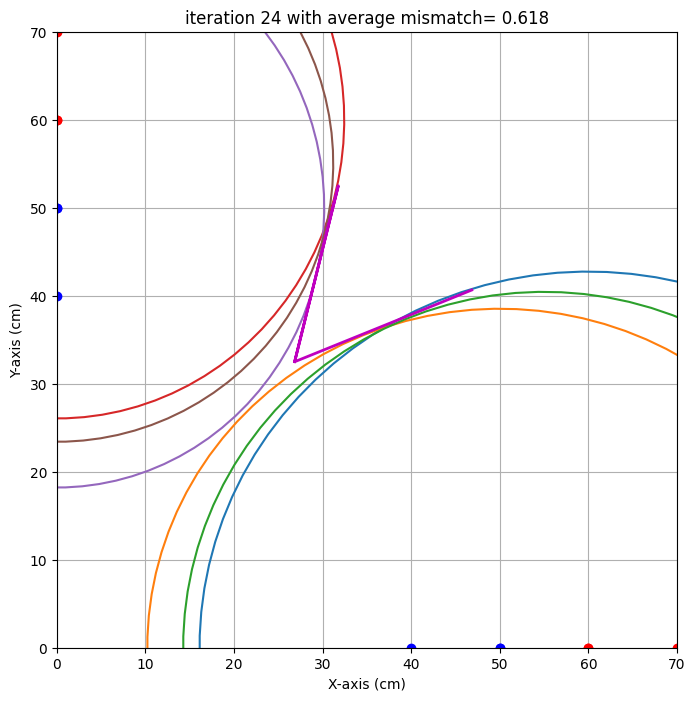

end iteration 24 with average mismatch= 0.618


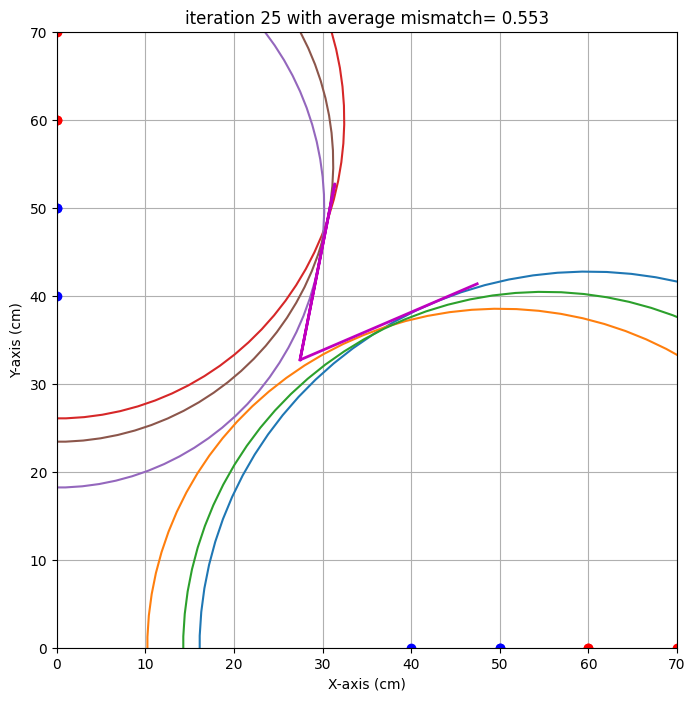

end iteration 25 with average mismatch= 0.553
end iteration 26 with average mismatch= 0.528
end iteration 27 with average mismatch= 0.508
end iteration 28 with average mismatch= 0.491


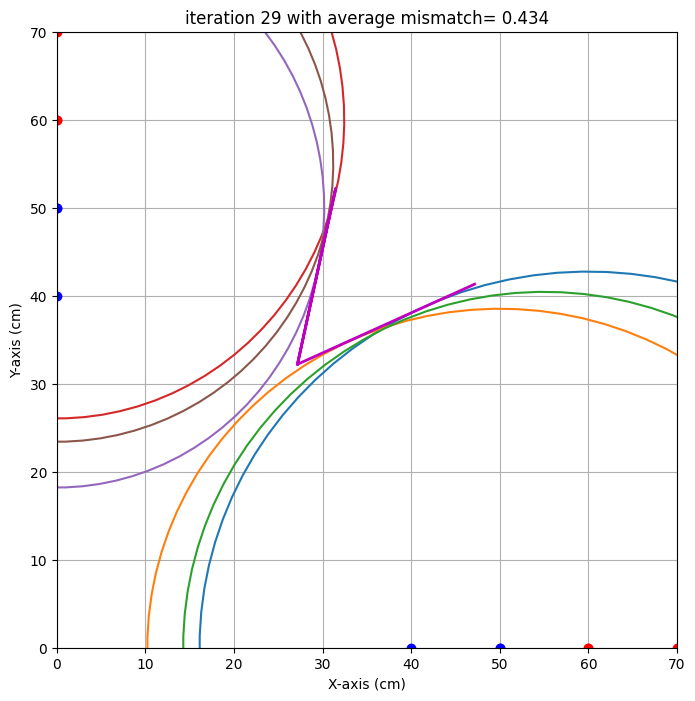

end iteration 29 with average mismatch= 0.434
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.432
###############################################################################
end of iteration  30
Best alpha=  24.47 with uncertainty=   3.24
Best beta =  12.16 with uncertainty=   5.85
Best x0   =  27.15 with uncertainty=   2.04
Best y0   =  32.21 with uncertainty=   1.09
###############################################################################


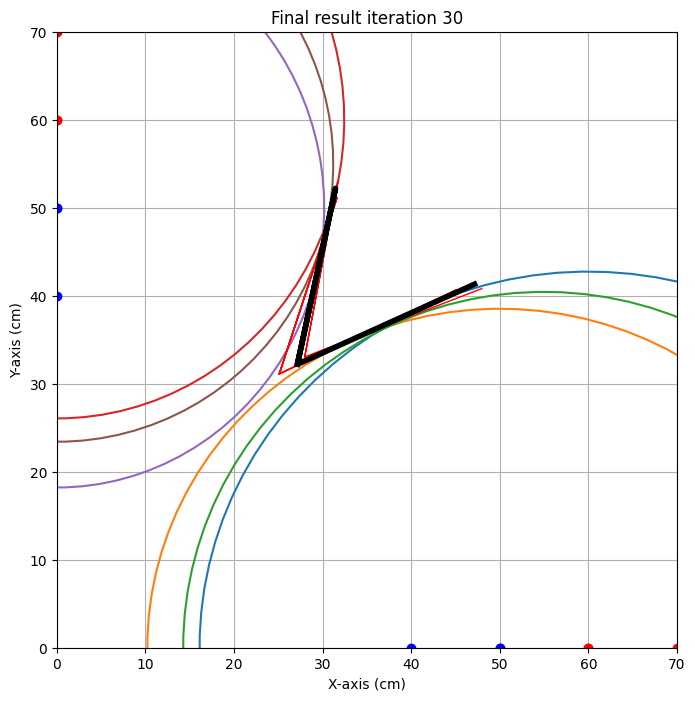

{'alpha': np.float64(24.469143649317033), 'alpha_eps': np.float64(3.243663526600219), 'beta': np.float64(12.160962795705075), 'beta_eps': np.float64(5.854767765227635), 'x0': np.float64(27.150156800513297), 'x0_eps': np.float64(2.041314305860567), 'y0': np.float64(32.208039867101064), 'y0_eps': np.float64(1.0937161335005605)}


In [9]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

In [10]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))

Yael Jawahierkhan 
x0 target is : 24.0. Gevonden waarde: 29.4 cm met een standaardafwijking van 4.1 cm 
y0 target is : 31.0. Gevonden waarde: 34.0 cm met een standaardafwijking van 3.5 cm 
alpha target is : 25.0. Gevonden waarde: 19.8 graden met een standaardafwijking van 10.1 graad 
beta target is : 10.0. Gevonden waarde: 7.6 graden met een standaardafwijking van 11.5 graad 

Matteo Leonardi 
x0 target is : 24.0. Gevonden waarde: 27.2 cm met een standaardafwijking van 2.0 cm 
y0 target is : 31.0. Gevonden waarde: 32.2 cm met een standaardafwijking van 1.1 cm 
alpha target is : 25.0. Gevonden waarde: 24.5 graden met een standaardafwijking van 3.2 graad 
beta target is : 10.0. Gevonden waarde: 12.2 graden met een standaardafwijking van 5.9 graad 



## Opdracht 8: Iteratie1+. 14:49.
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Figuur: 

![Alt](Iteratie1.jpeg)


In [11]:
# Voeg hier eventueel (nieuwe) code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 9: Iteratie 1+ meeting en test

locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  70   0  50   0  87.8
1  60   0  40   0  79.6
2  60   0  50   0  81.5
3   0  70   0  50  67.9
4   0  60   0  40  63.6
5   0  60   0  50  63.2
6  70   0  40   0  84.4
7   0  70   0  40  68.7


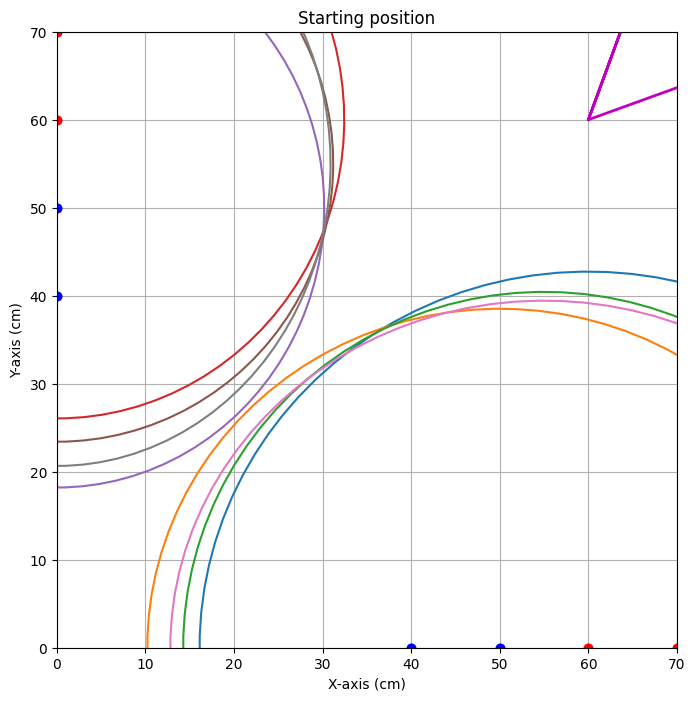


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=53.529


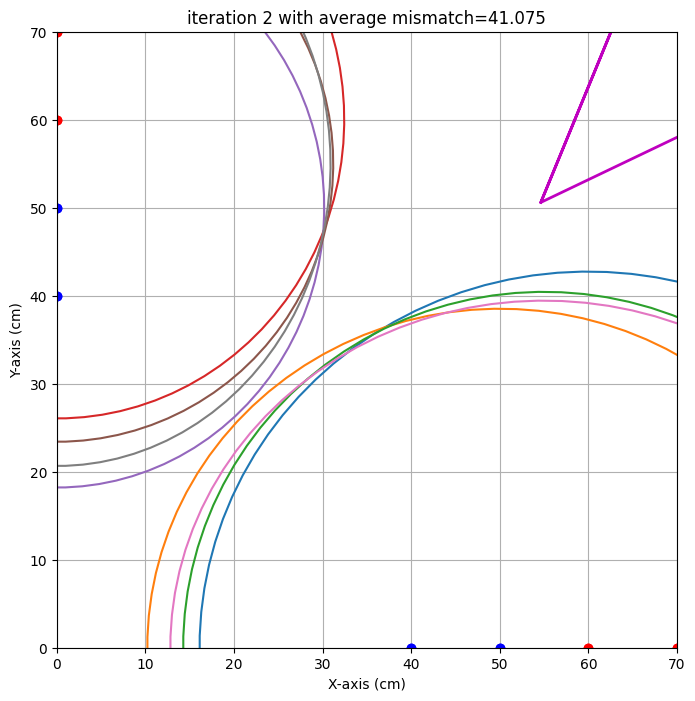

end iteration 2 with average mismatch=41.075


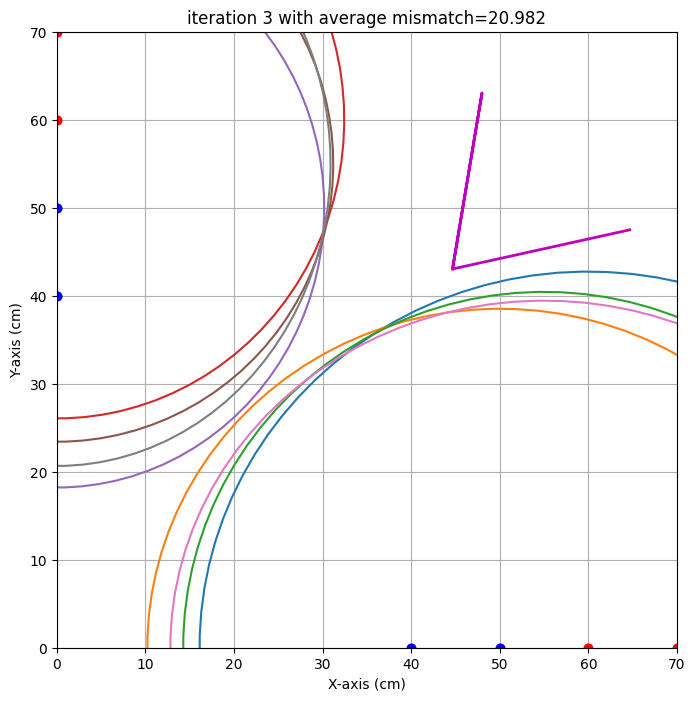

end iteration 3 with average mismatch=20.982


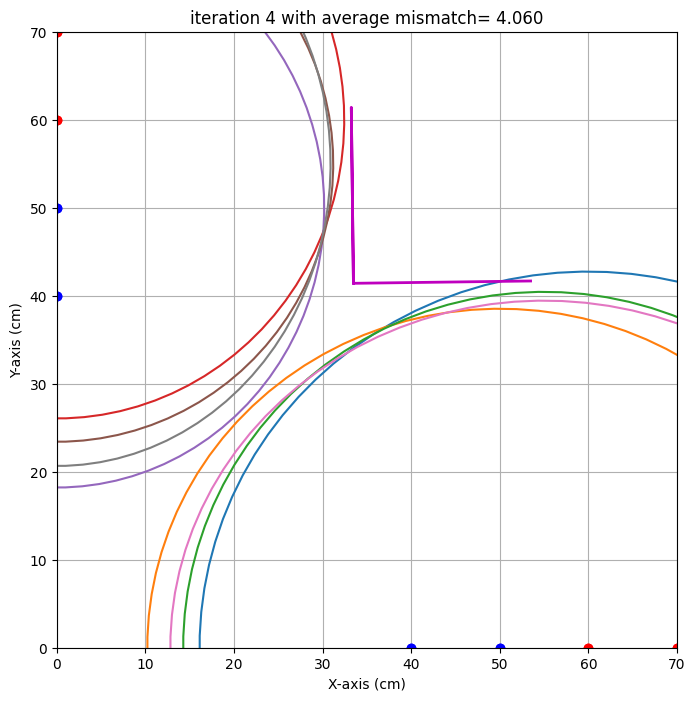

end iteration 4 with average mismatch= 4.060


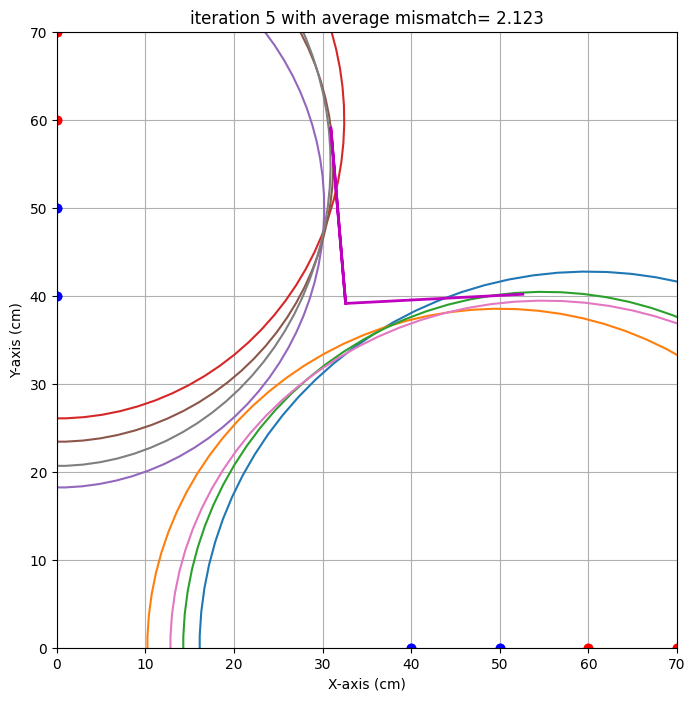

end iteration 5 with average mismatch= 2.123


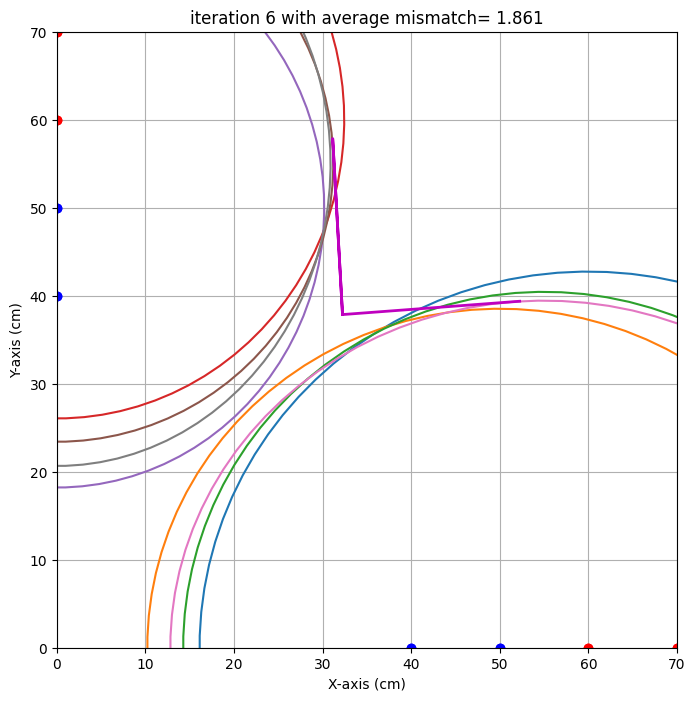

end iteration 6 with average mismatch= 1.861
end iteration 7 with average mismatch= 1.847
end iteration 8 with average mismatch= 1.761


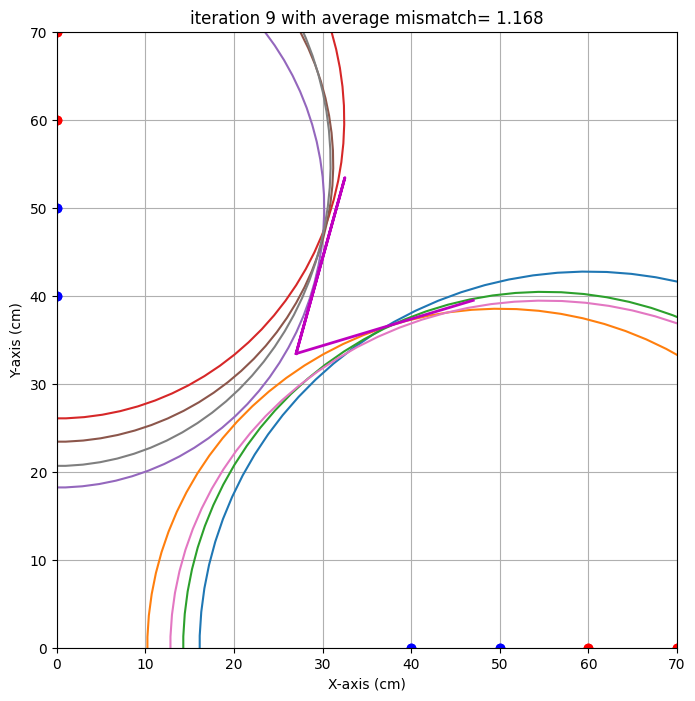

end iteration 9 with average mismatch= 1.168


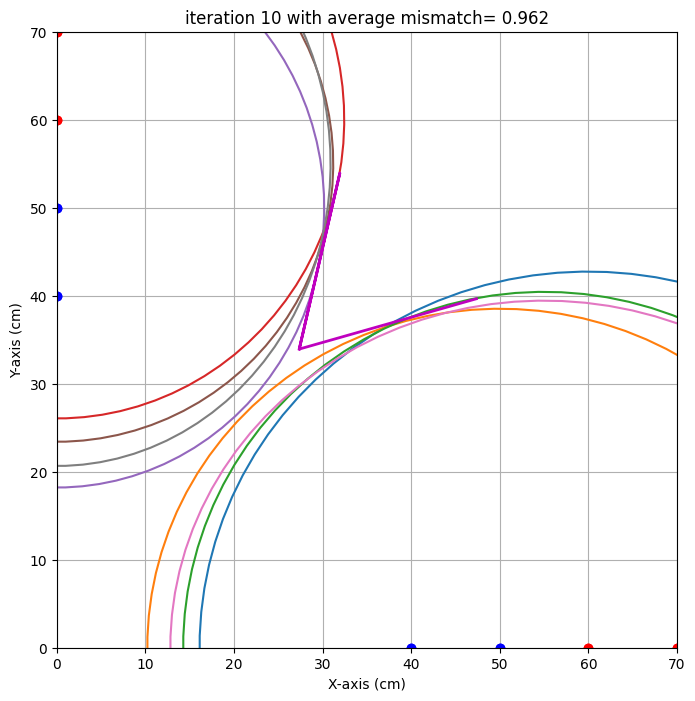

end iteration 10 with average mismatch= 0.962
end iteration 11 with average mismatch= 0.896
end iteration 12 with average mismatch= 0.891
end iteration 13 with average mismatch= 0.890
end iteration 14 with average mismatch= 0.890
end iteration 15 with average mismatch= 0.890
end iteration 16 with average mismatch= 0.890
end iteration 17 with average mismatch= 0.890
end iteration 18 with average mismatch= 0.890
end iteration 19 with average mismatch= 0.829
end iteration 20 with average mismatch= 0.754
end iteration 21 with average mismatch= 0.738
end iteration 22 with average mismatch= 0.729
end iteration 23 with average mismatch= 0.724
end iteration 24 with average mismatch= 0.724
end iteration 25 with average mismatch= 0.724
end iteration 26 with average mismatch= 0.694
end iteration 27 with average mismatch= 0.655
end iteration 28 with average mismatch= 0.653
end iteration 29 with average mismatch= 0.653
Last iteration, also determine uncertainty, wait a while..
wait a little longer.

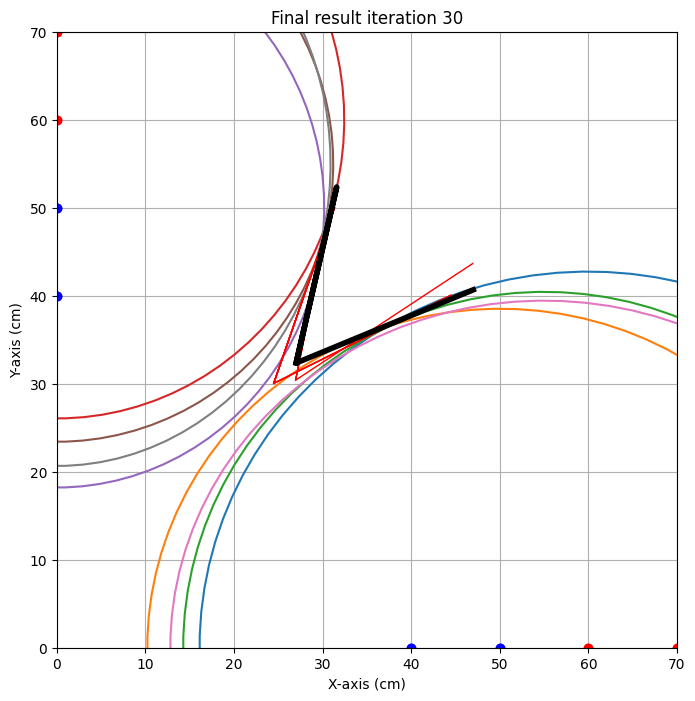

{'alpha': np.float64(22.579073678940123), 'alpha_eps': np.float64(10.95641685454628), 'beta': np.float64(12.896573946939894), 'beta_eps': np.float64(6.071508983901667), 'x0': np.float64(27.009722922335772), 'x0_eps': np.float64(2.5337515047980546), 'y0': np.float64(32.355976961788784), 'y0_eps': np.float64(2.3200199563012376)}
locatie 2
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  70   0  50   0  72.2
1  60   0  40   0  70.6
2  60   0  50   0  69.0
3   0  70   0  50  94.5
4   0  60   0  40  93.5
5   0  60   0  50  90.4
6  70   0  40   0  75.4
7   0  70   0  40  93.4


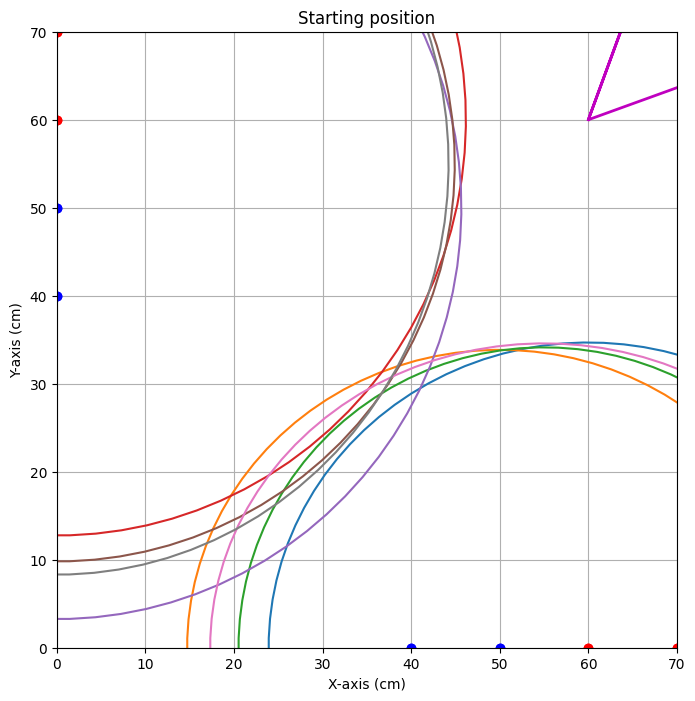


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=45.741


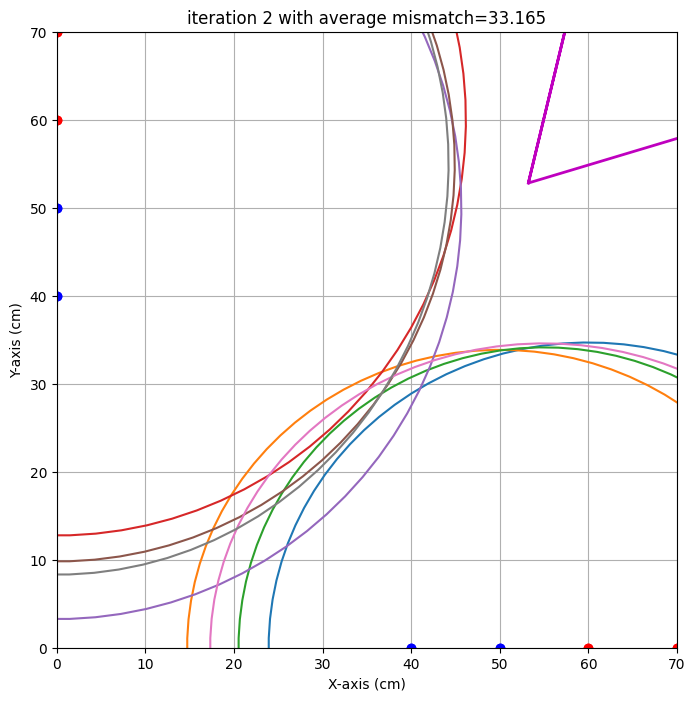

end iteration 2 with average mismatch=33.165


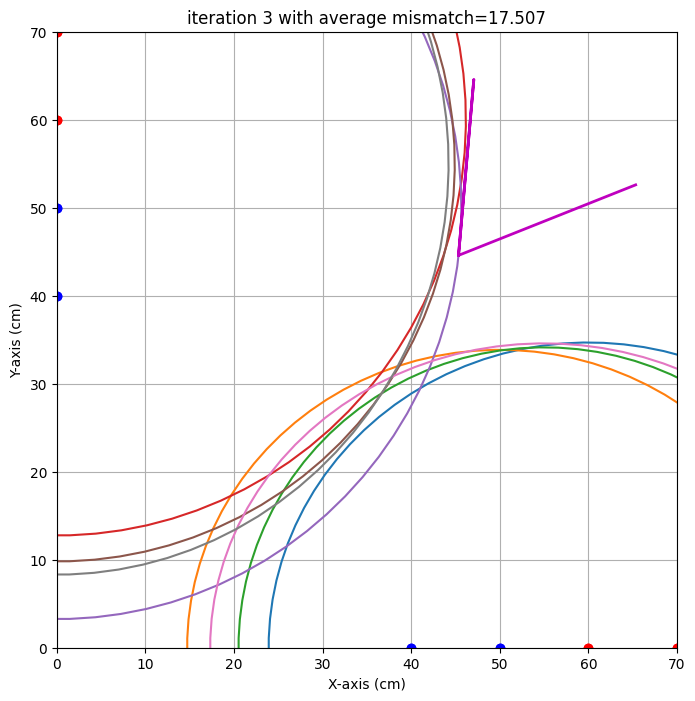

end iteration 3 with average mismatch=17.507


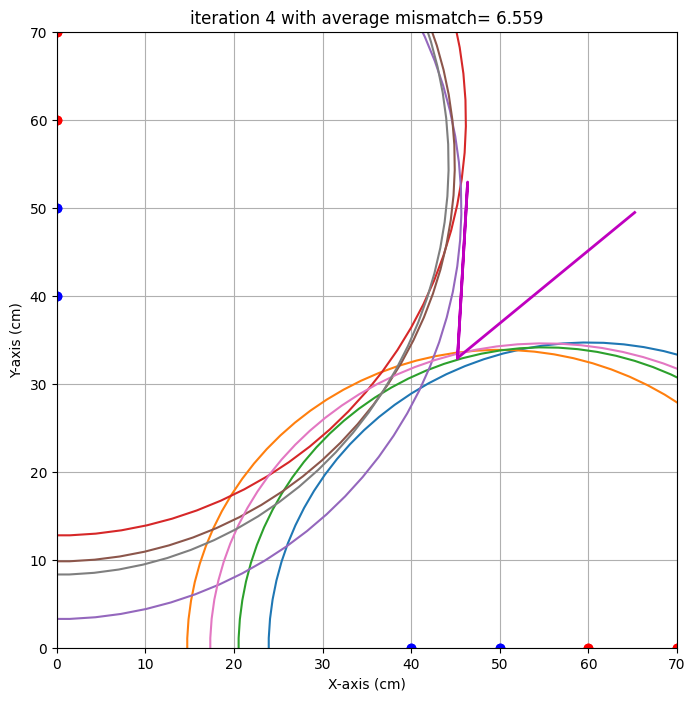

end iteration 4 with average mismatch= 6.559


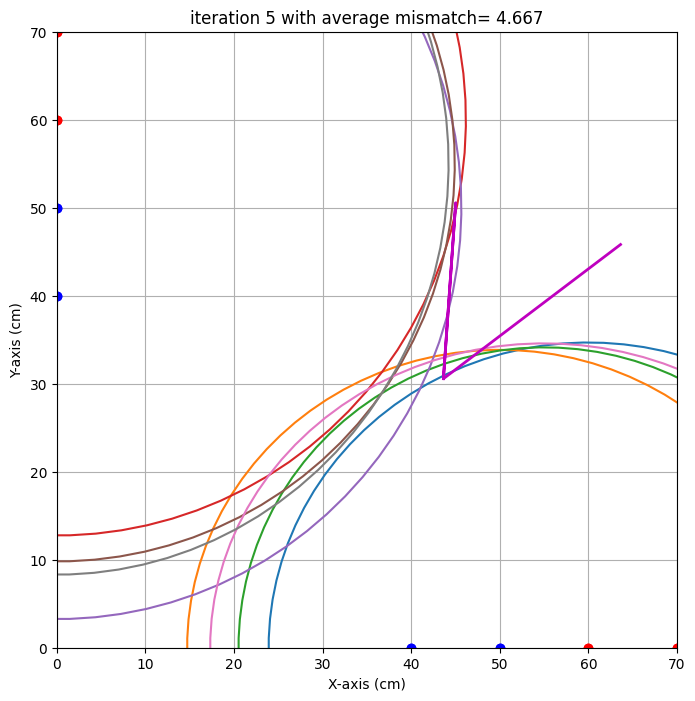

end iteration 5 with average mismatch= 4.667


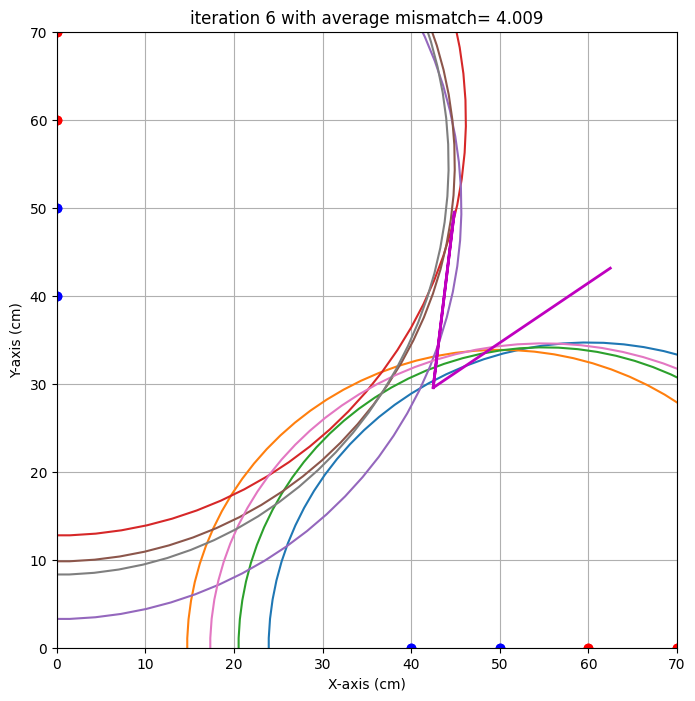

end iteration 6 with average mismatch= 4.009


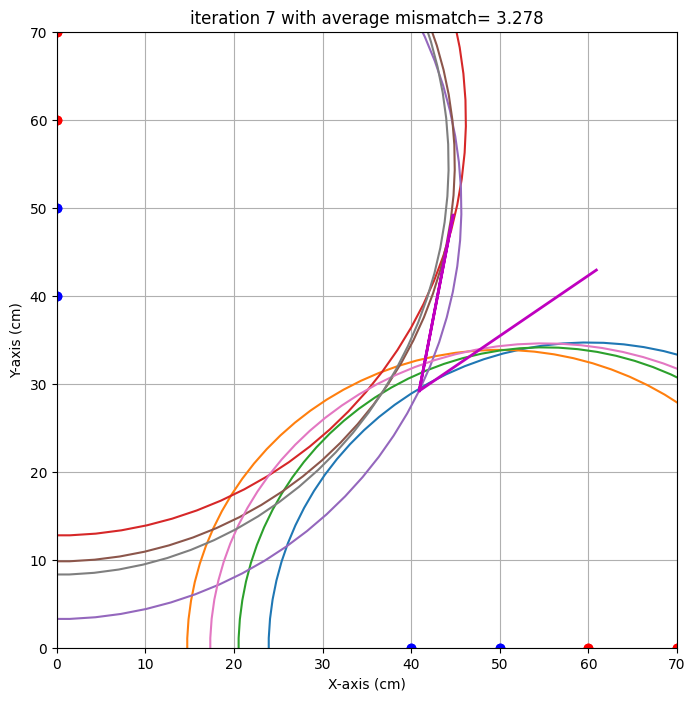

end iteration 7 with average mismatch= 3.278
end iteration 8 with average mismatch= 3.165
end iteration 9 with average mismatch= 3.158
end iteration 10 with average mismatch= 3.145
end iteration 11 with average mismatch= 3.140
end iteration 12 with average mismatch= 3.140
end iteration 13 with average mismatch= 3.140
end iteration 14 with average mismatch= 3.140
end iteration 15 with average mismatch= 3.140
end iteration 16 with average mismatch= 3.067


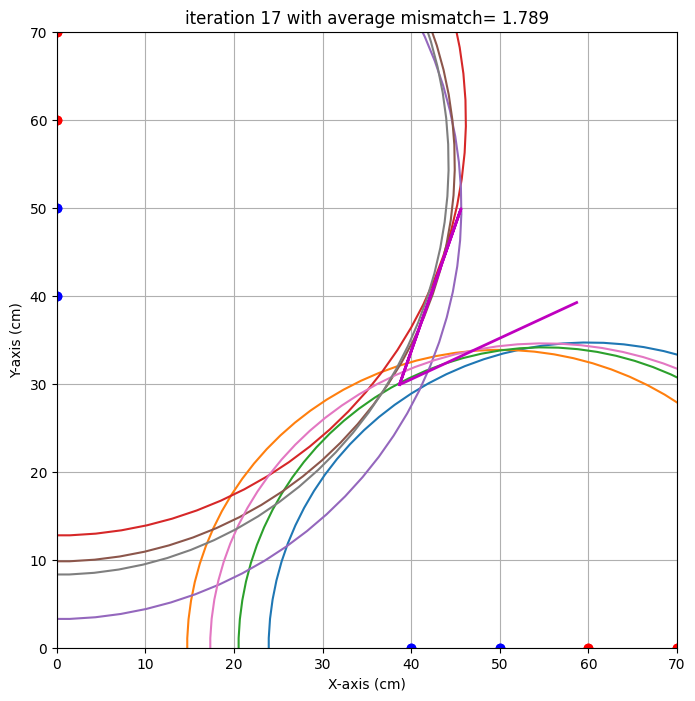

end iteration 17 with average mismatch= 1.789


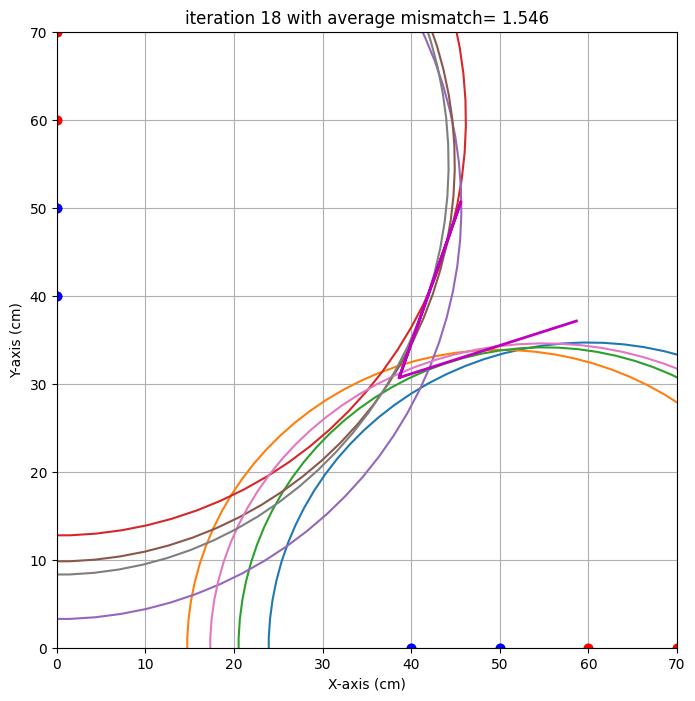

end iteration 18 with average mismatch= 1.546


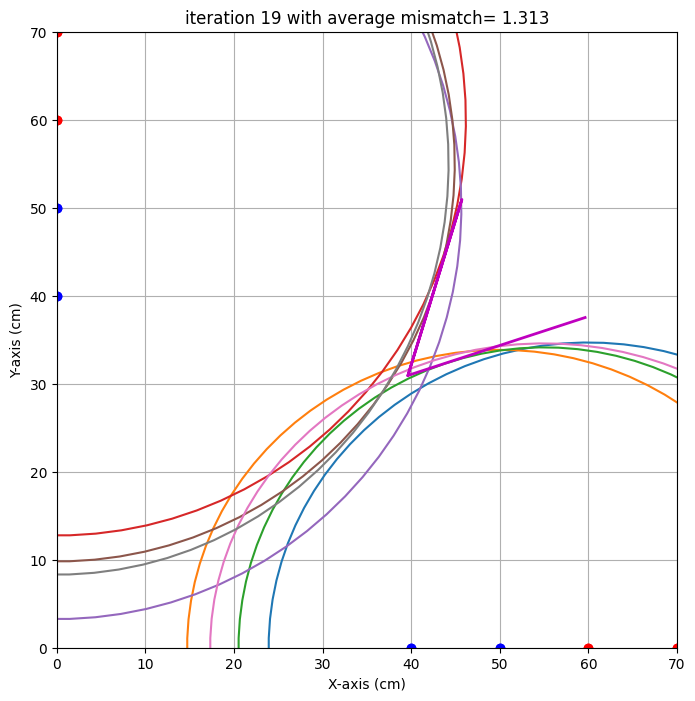

end iteration 19 with average mismatch= 1.313


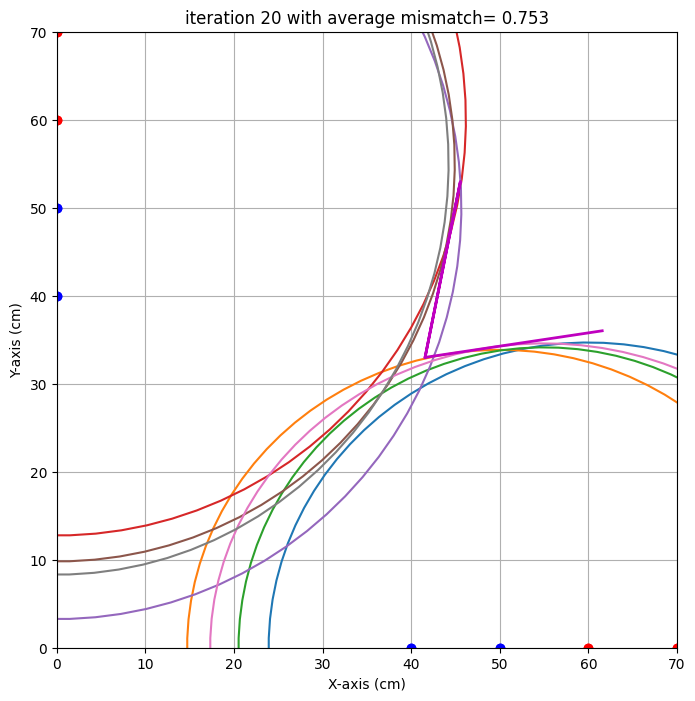

end iteration 20 with average mismatch= 0.753
end iteration 21 with average mismatch= 0.753
end iteration 22 with average mismatch= 0.716
end iteration 23 with average mismatch= 0.716
end iteration 24 with average mismatch= 0.716
end iteration 25 with average mismatch= 0.716
end iteration 26 with average mismatch= 0.699
end iteration 27 with average mismatch= 0.687
end iteration 28 with average mismatch= 0.677
end iteration 29 with average mismatch= 0.664
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.662
###############################################################################
end of iteration  30
Best alpha=   5.47 with uncertainty=   4.13
Best beta =  11.64 with uncertainty=   2.73
Best x0   =  41.39 with uncertainty=   0.94
Best y0   =  33.19 with uncertainty=   1.34
###############################################################################


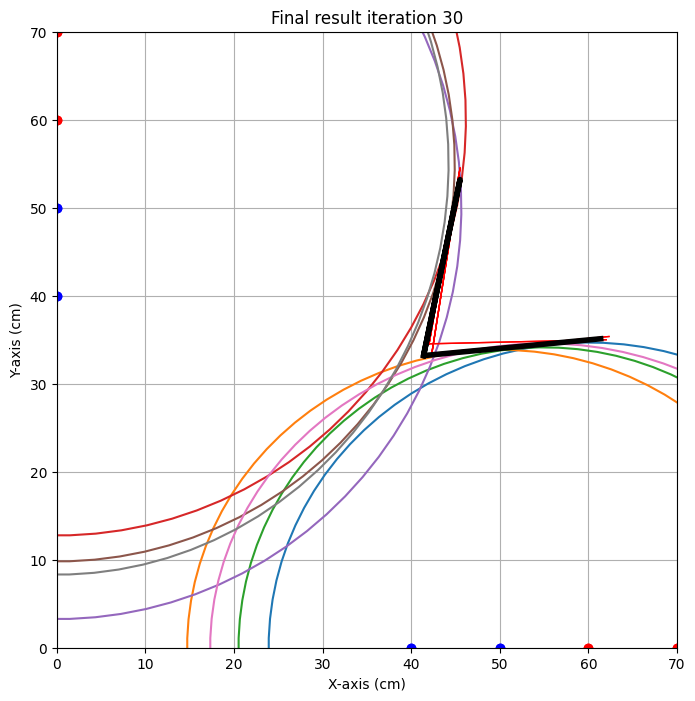

{'alpha': np.float64(5.46819391027831), 'alpha_eps': np.float64(4.132221047495169), 'beta': np.float64(11.640877178731763), 'beta_eps': np.float64(2.7283424756575165), 'x0': np.float64(41.393171729167406), 'x0_eps': np.float64(0.9362927496422415), 'y0': np.float64(33.19459993130185), 'y0_eps': np.float64(1.3384050786912596)}
locatie 1 
x0 target is : 24.0. Gevonden waarde: 27.0 cm met een standaardafwijking van 2.5 cm 
y0 target is : 31.0. Gevonden waarde: 32.4 cm met een standaardafwijking van 2.3 cm 
alpha target is : 25.0. Gevonden waarde: 22.6 graden met een standaardafwijking van 11.0 graad 
beta target is : 10.0. Gevonden waarde: 12.9 graden met een standaardafwijking van 6.1 graad 

locatie 2 
x0 target is : 37.0. Gevonden waarde: 41.4 cm met een standaardafwijking van 0.9 cm 
y0 target is : 32.9. Gevonden waarde: 33.2 cm met een standaardafwijking van 1.3 cm 
alpha target is : 4.0. Gevonden waarde: 5.5 graden met een standaardafwijking van 4.1 graad 
beta target is : 23.0. Gevo

In [12]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0': 24,
                    'y0': 31,
                    'alpha' : 25,
                    'beta' : 10},
           'locatie 2':{'x0': 37 ,
                    'y0': 32.9,
                    'alpha' : 4 ,
                    'beta' : 23 }
            }
           
# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
      [70,0,50,0,87.8],
    [60,0,40,0,79.6],
    [60,0,50,0,81.5],
    [0,70,0,50,67.9],  
    [0,60,0,40,63.6],
    [0,60,0,50,63.2],
    [70,0,40,0,84.4],
    [0,70,0,40,68.7],
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
      [70,0,50,0,72.2],
    [60,0,40,0,70.6],
    [60,0,50,0,69.0],
    [0,70,0,50,94.5],  
    [0,60,0,40,93.5],
    [0,60,0,50,90.4],
    [70,0,40,0,75.4],
    [0,70,0,40,93.4],
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

Iteratie 2:

locatie 1
Running the imaging algorithm with the following data:
    xs  ys  xr  yr     R
0   70   0  50   0  88.6
1   70   0  70   0  93.6
2   60   0  50   0  86.5
3   65   0  55   0  88.6
4   70   0  55   0  93.3
5   65   0  50   0  88.3
6    0  70   0  50  75.5
7    0  60   0  40  69.5
8    0  60   0  50  66.8
9    0  70   0  40  74.0
10   0  65   0  45  66.1
11   0  70   0  45  69.8


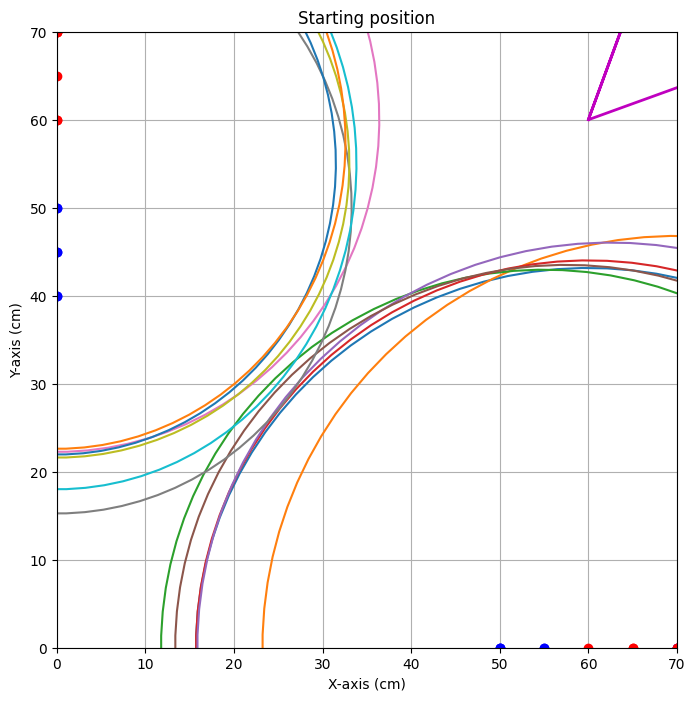


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=47.308


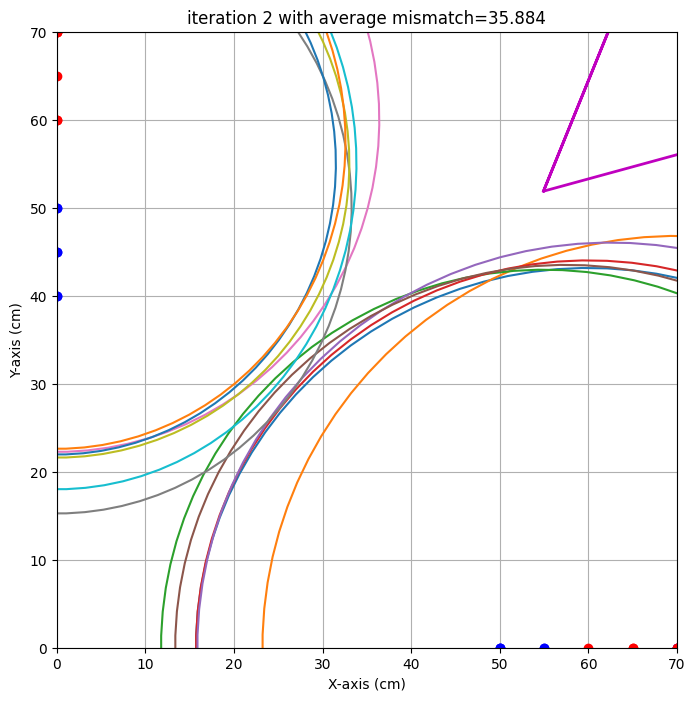

end iteration 2 with average mismatch=35.884


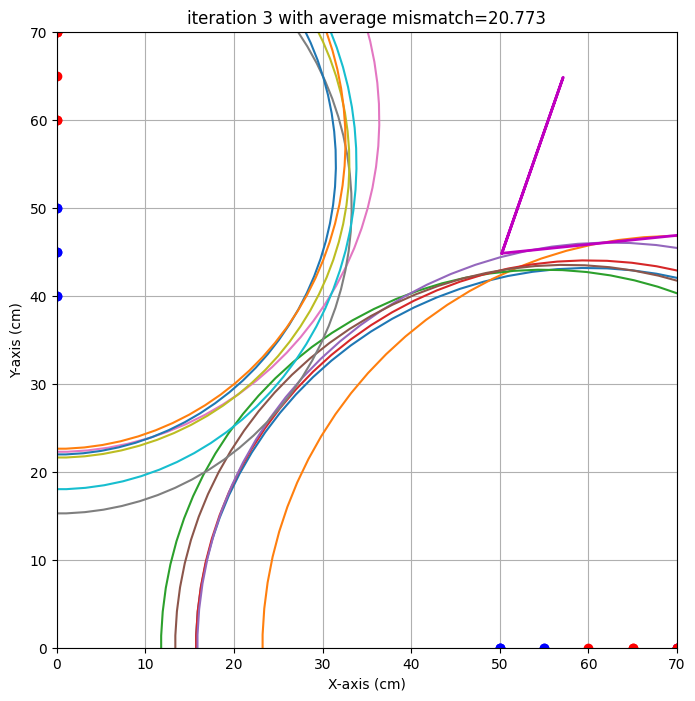

end iteration 3 with average mismatch=20.773


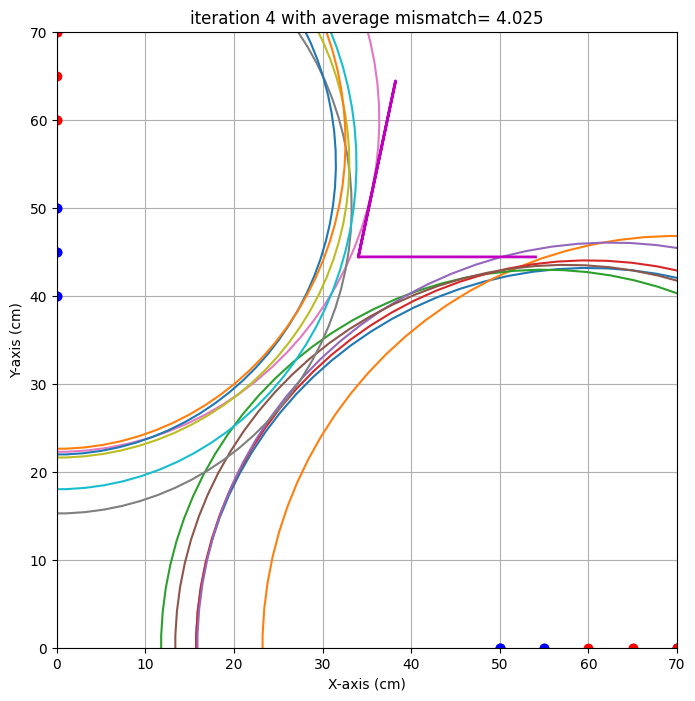

end iteration 4 with average mismatch= 4.025


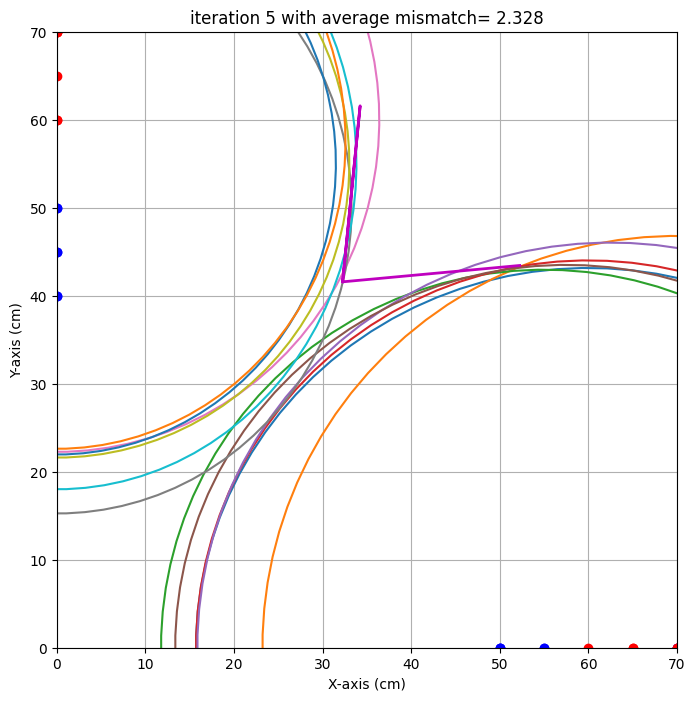

end iteration 5 with average mismatch= 2.328


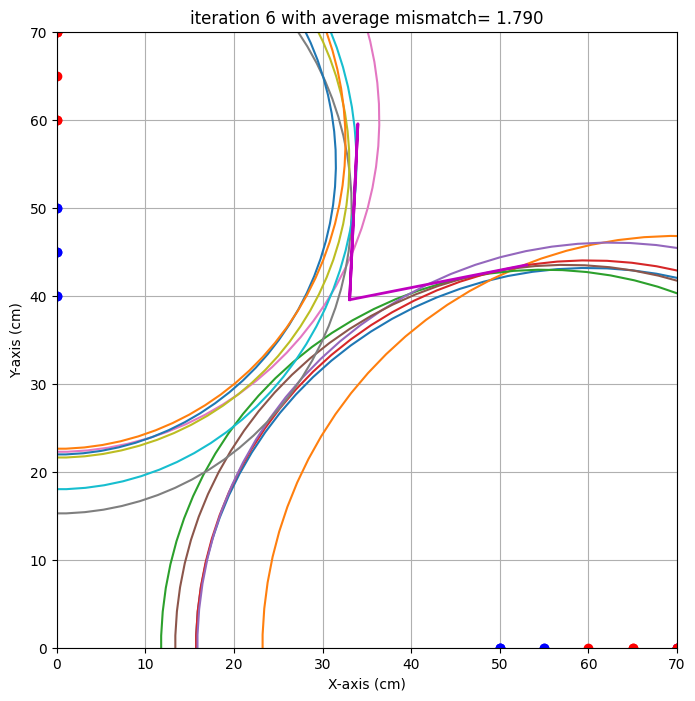

end iteration 6 with average mismatch= 1.790
end iteration 7 with average mismatch= 1.763
end iteration 8 with average mismatch= 1.752
end iteration 9 with average mismatch= 1.748
end iteration 10 with average mismatch= 1.747
end iteration 11 with average mismatch= 1.747
end iteration 12 with average mismatch= 1.747
end iteration 13 with average mismatch= 1.747
end iteration 14 with average mismatch= 1.739
end iteration 15 with average mismatch= 1.733
end iteration 16 with average mismatch= 1.733
end iteration 17 with average mismatch= 1.733
end iteration 18 with average mismatch= 1.733
end iteration 19 with average mismatch= 1.733
end iteration 20 with average mismatch= 1.733
end iteration 21 with average mismatch= 1.644
end iteration 22 with average mismatch= 1.615
end iteration 23 with average mismatch= 1.615
end iteration 24 with average mismatch= 1.615
end iteration 25 with average mismatch= 1.615
end iteration 26 with average mismatch= 1.615
end iteration 27 with average mismatch

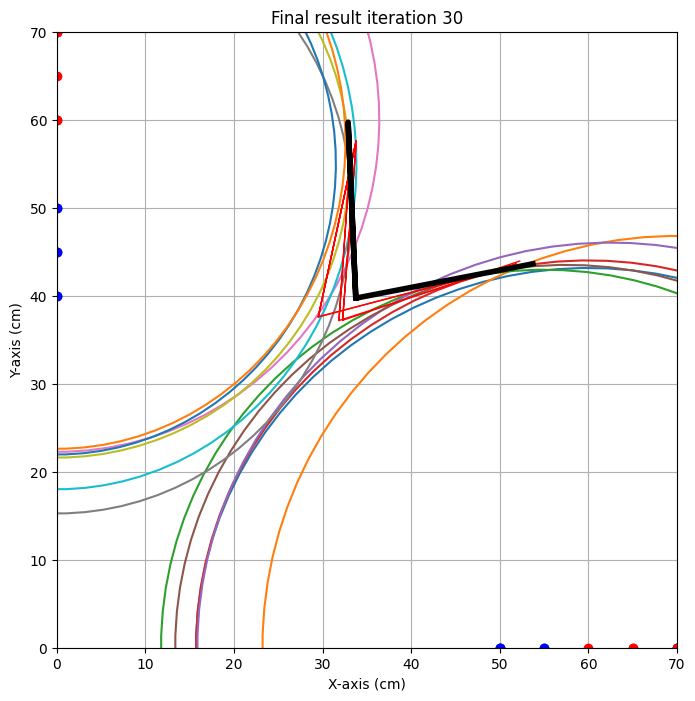

{'alpha': np.float64(11.04025312505891), 'alpha_eps': np.float64(7.552602479504852), 'beta': np.float64(-2.4832463041531687), 'beta_eps': np.float64(14.54535339474722), 'x0': np.float64(33.74565131144357), 'x0_eps': np.float64(4.2353558632174675), 'y0': np.float64(39.72433494269243), 'y0_eps': np.float64(2.5404950726811606)}
locatie 2
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  70   0  50   0  72.2
1  60   0  40   0  70.6
2  60   0  50   0  69.0
3   0  70   0  50  94.5
4   0  60   0  40  93.5
5   0  60   0  50  90.4
6  70   0  40   0  75.4
7   0  70   0  40  93.4


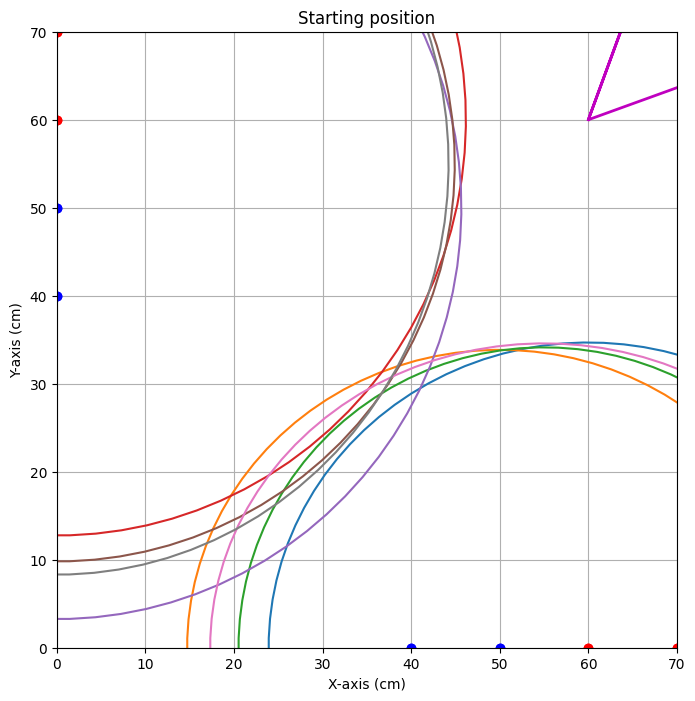


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=45.741


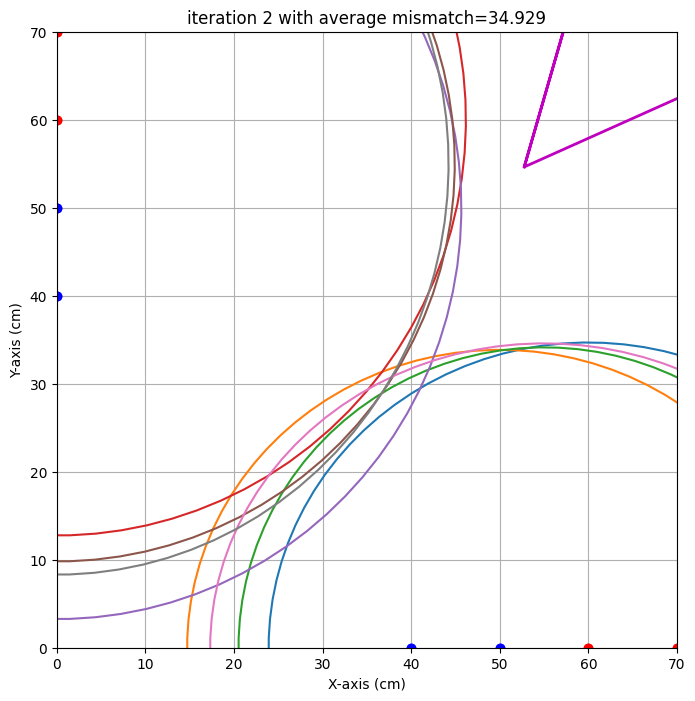

end iteration 2 with average mismatch=34.929


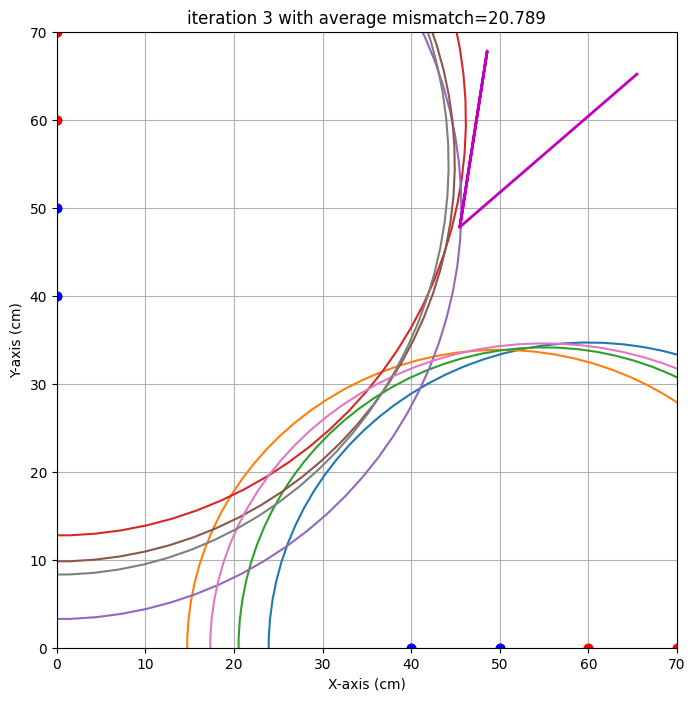

end iteration 3 with average mismatch=20.789


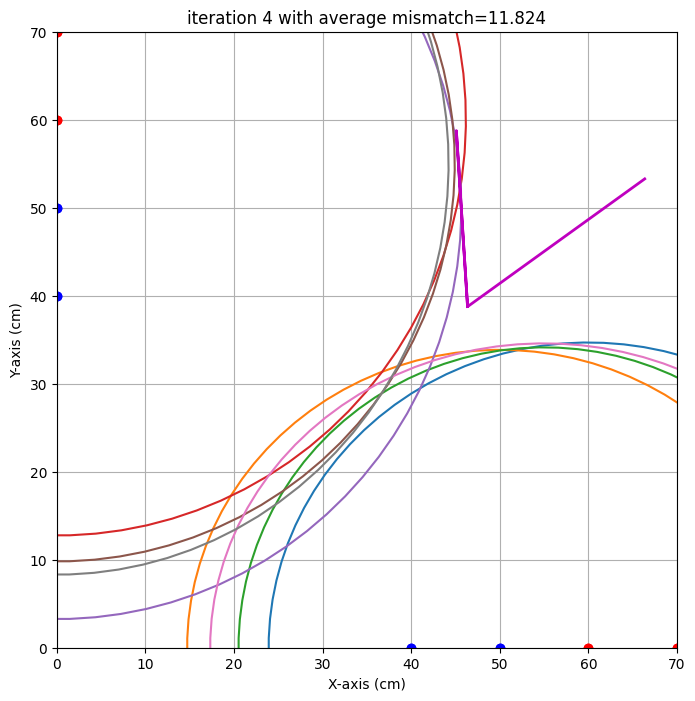

end iteration 4 with average mismatch=11.824


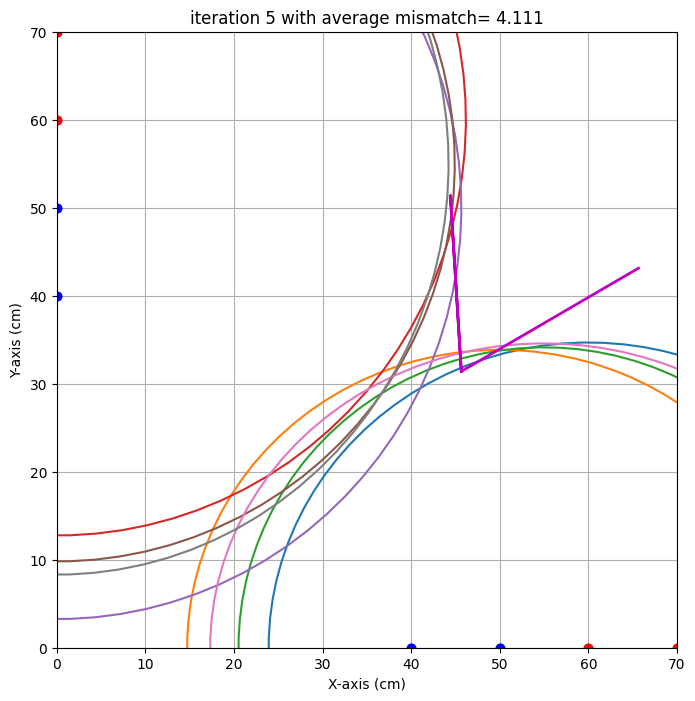

end iteration 5 with average mismatch= 4.111


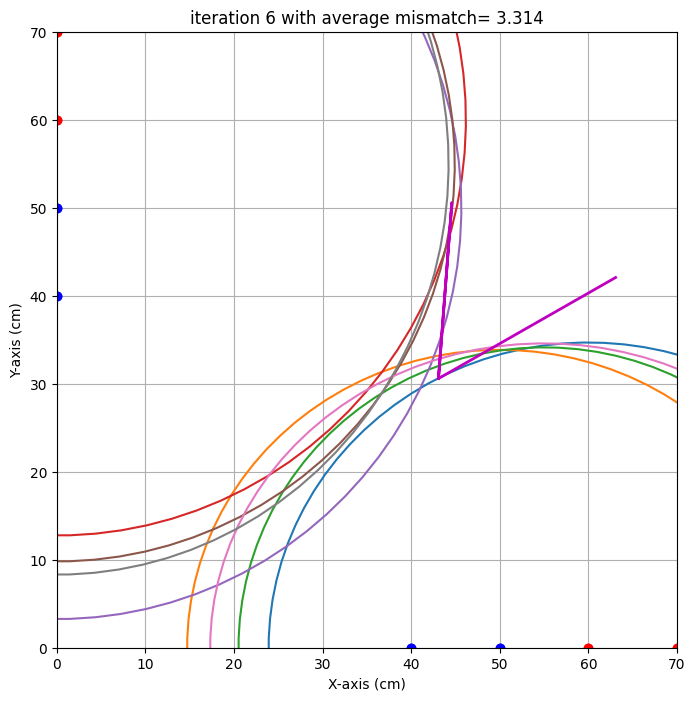

end iteration 6 with average mismatch= 3.314


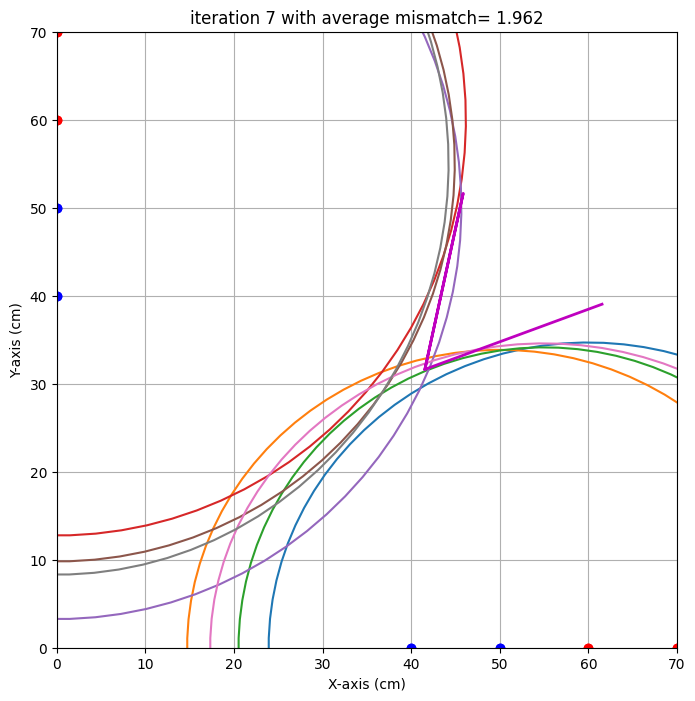

end iteration 7 with average mismatch= 1.962


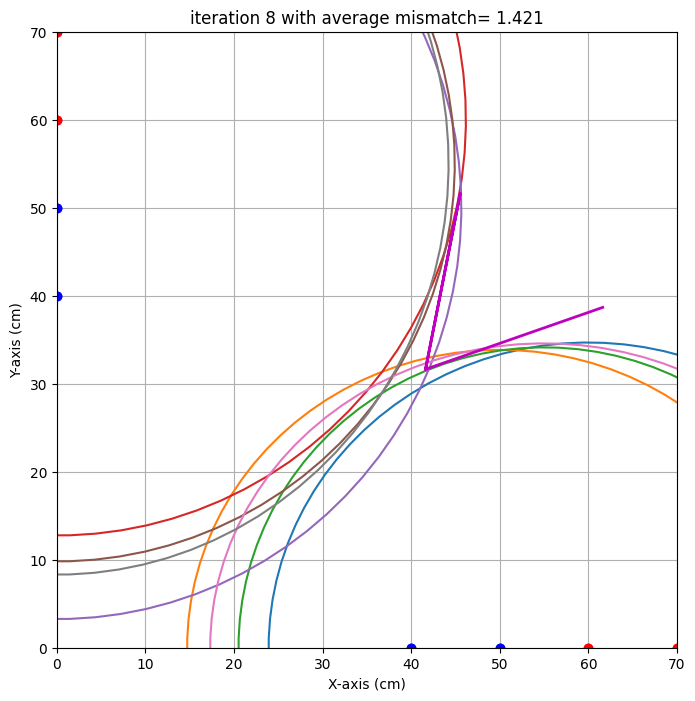

end iteration 8 with average mismatch= 1.421


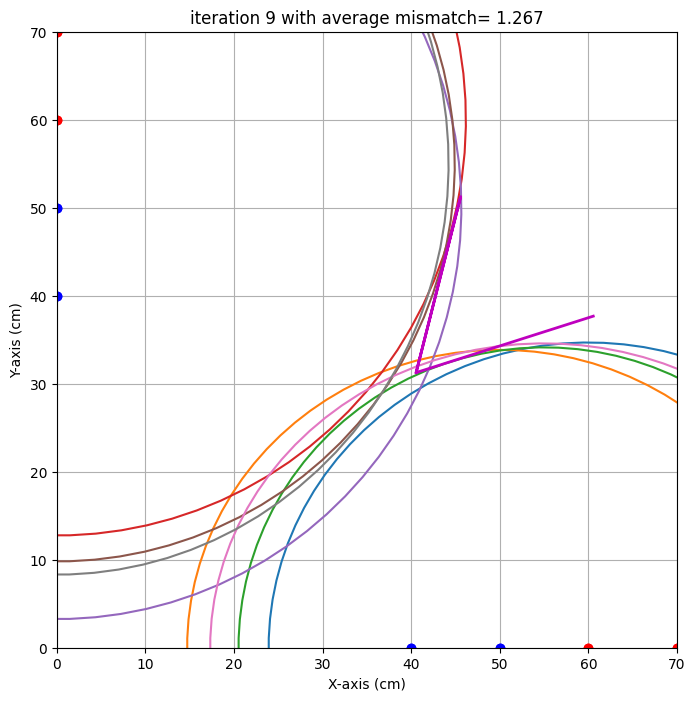

end iteration 9 with average mismatch= 1.267


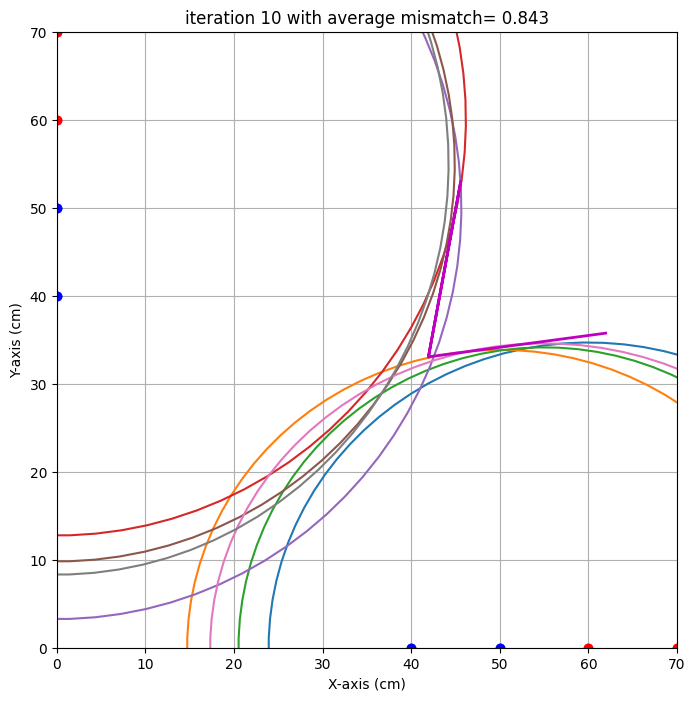

end iteration 10 with average mismatch= 0.843
end iteration 11 with average mismatch= 0.790
end iteration 12 with average mismatch= 0.739
end iteration 13 with average mismatch= 0.725
end iteration 14 with average mismatch= 0.725
end iteration 15 with average mismatch= 0.725
end iteration 16 with average mismatch= 0.725
end iteration 17 with average mismatch= 0.725
end iteration 18 with average mismatch= 0.725
end iteration 19 with average mismatch= 0.725
end iteration 20 with average mismatch= 0.725
end iteration 21 with average mismatch= 0.717
end iteration 22 with average mismatch= 0.707
end iteration 23 with average mismatch= 0.707
end iteration 24 with average mismatch= 0.706
end iteration 25 with average mismatch= 0.706
end iteration 26 with average mismatch= 0.706
end iteration 27 with average mismatch= 0.706
end iteration 28 with average mismatch= 0.706
end iteration 29 with average mismatch= 0.706
Last iteration, also determine uncertainty, wait a while..
wait a little longer.

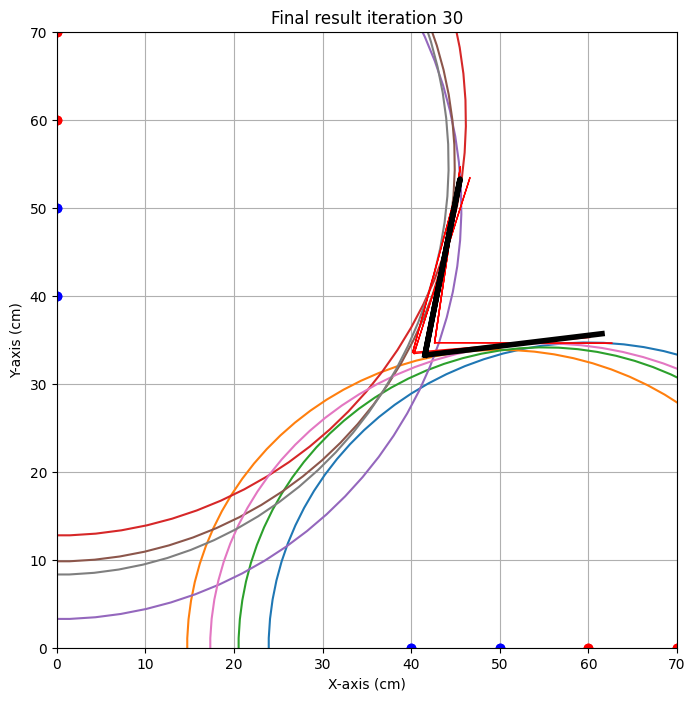

{'alpha': np.float64(6.939729968000663), 'alpha_eps': np.float64(7.0867900540077144), 'beta': np.float64(11.230845048117876), 'beta_eps': np.float64(6.274418199739186), 'x0': np.float64(41.543953302059826), 'x0_eps': np.float64(1.3766875309523883), 'y0': np.float64(33.247857249780495), 'y0_eps': np.float64(1.4069273619475595)}
locatie 1 
x0 target is : 31.0. Gevonden waarde: 33.7 cm met een standaardafwijking van 4.2 cm 
y0 target is : 32.7. Gevonden waarde: 39.7 cm met een standaardafwijking van 2.5 cm 
alpha target is : 38.0. Gevonden waarde: 11.0 graden met een standaardafwijking van 7.6 graad 
beta target is : 7.0. Gevonden waarde: -2.5 graden met een standaardafwijking van 14.5 graad 

locatie 2 
x0 target is : 37.0. Gevonden waarde: 41.5 cm met een standaardafwijking van 1.4 cm 
y0 target is : 32.9. Gevonden waarde: 33.2 cm met een standaardafwijking van 1.4 cm 
alpha target is : 4.0. Gevonden waarde: 6.9 graden met een standaardafwijking van 7.1 graad 
beta target is : 23.0. Gev

In [13]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0': 31,
                    'y0': 32.7,
                    'alpha' : 38,
                    'beta' : 7},
           'locatie 2':{'x0': 37 ,
                    'y0': 32.9,
                    'alpha' : 4 ,
                    'beta' : 23 }
            }
           
# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
      [70,0,50,0,88.6],
    #[60,0,40,0,200],
    [70,0,70,0,93.6],
    [60,0,50,0,86.5],
    [65,0,55,0,88.6],
    [70,0,55,0,93.3],  
    [65,0,50,0,88.3],
    [0,70,0,50,75.5],
    [0,60,0,40,69.5],
    [0,60,0,50,66.8],
    [0,70,0,40,74.0],
    [0,65,0,45,66.1],
    #[0,70,0,60,200],
    #[0,70,0,55,200],
    [0,70,0,45,69.8],

   
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
      [70,0,50,0,72.2],
    [60,0,40,0,70.6],
    [60,0,50,0,69.0],
    [0,70,0,50,94.5],  
    [0,60,0,40,93.5],
    [0,60,0,50,90.4],
    [70,0,40,0,75.4],
    [0,70,0,40,93.4],
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

test locatie
Running the imaging algorithm with the following data:
    xs  ys  xr  yr     R
0   70   0  50   0  92.2
1   60   0  40   0  93.5
2   60   0  50   0  89.2
3   70   0  40   0  93.5
4   65   0  45   0  91.0
5   70   0  45   0  93.5
6    0  20   0  40  95.3
7    0  30   0  50  89.5
8    0  30   0  40  89.0
9    0  20   0  50  93.2
10   0  25   0  45  90.9
11   0  35   0  25  95.5


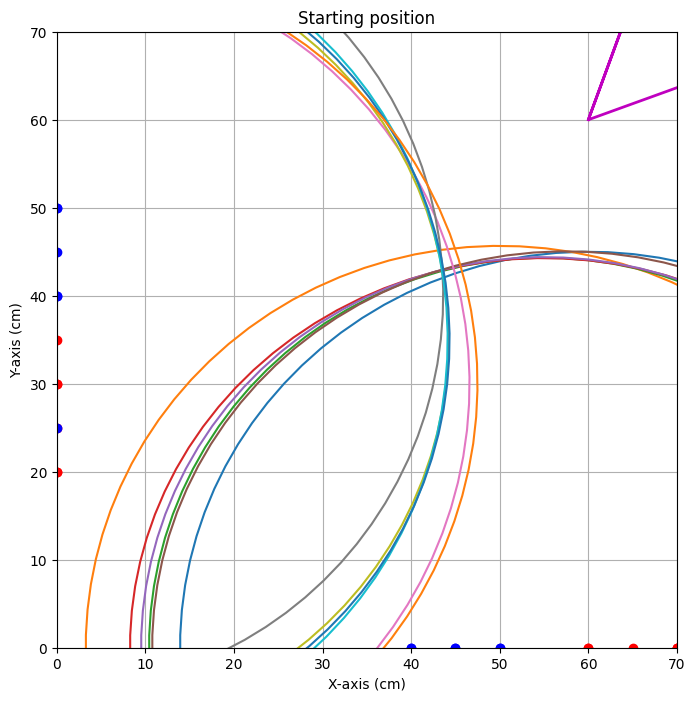


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=42.009


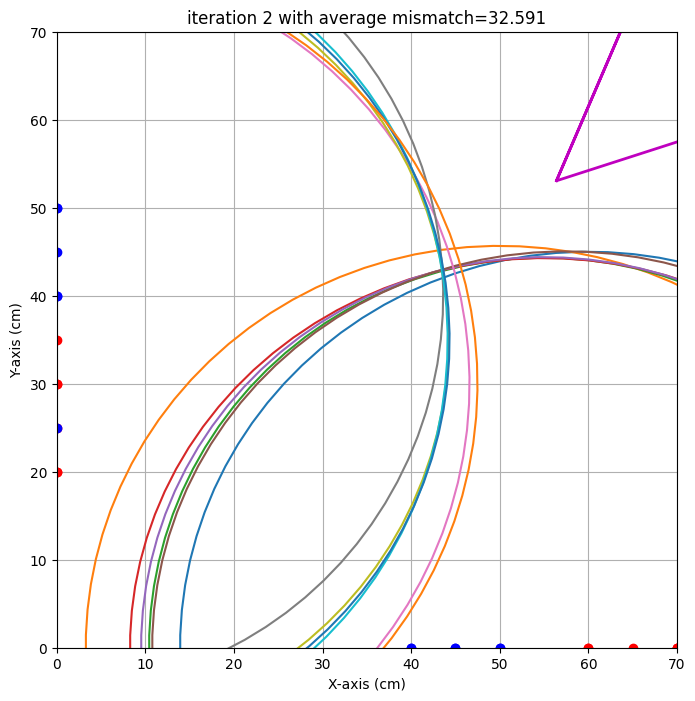

end iteration 2 with average mismatch=32.591


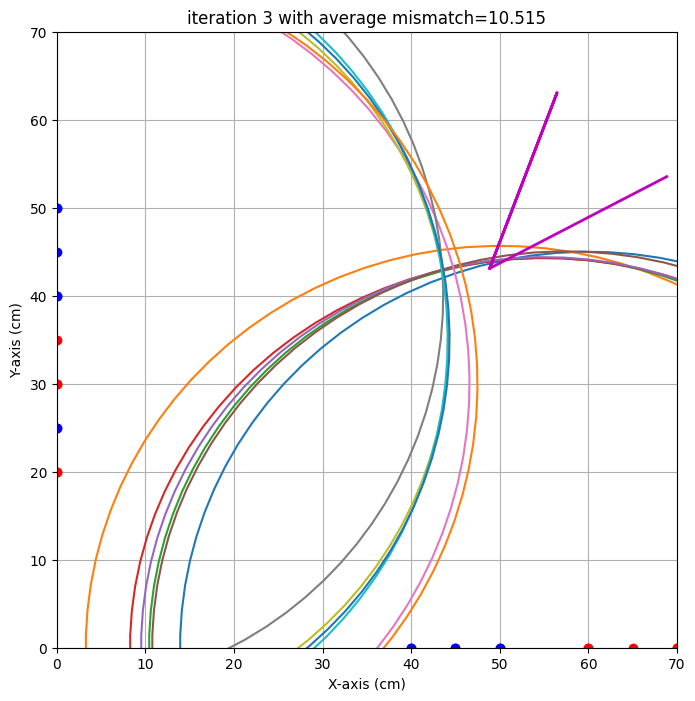

end iteration 3 with average mismatch=10.515


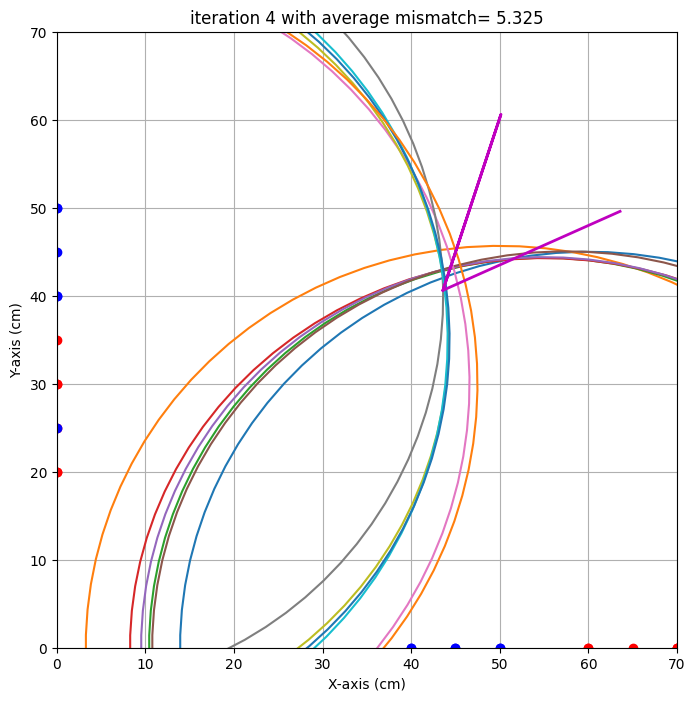

end iteration 4 with average mismatch= 5.325


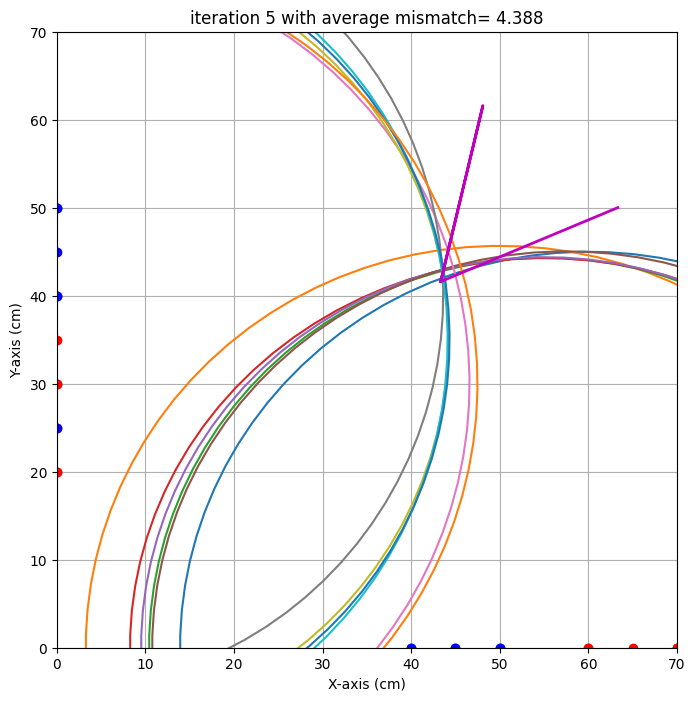

end iteration 5 with average mismatch= 4.388


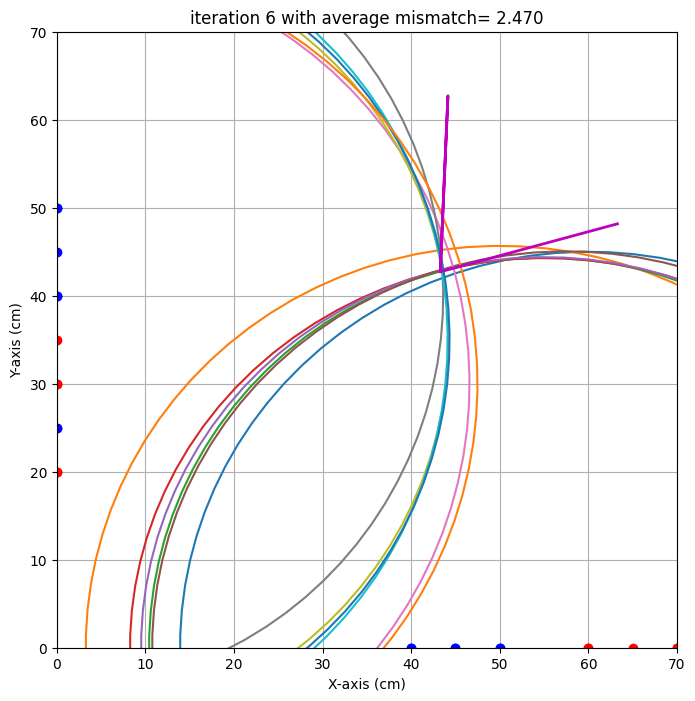

end iteration 6 with average mismatch= 2.470


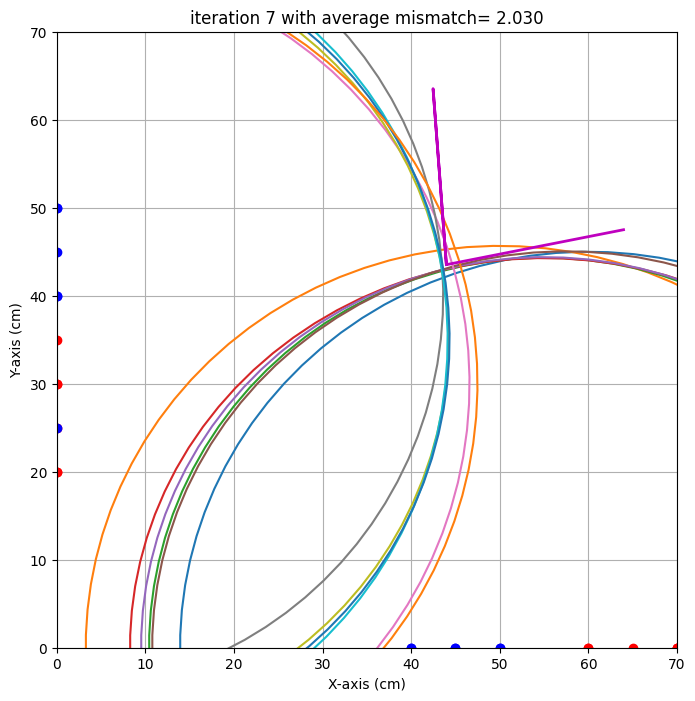

end iteration 7 with average mismatch= 2.030


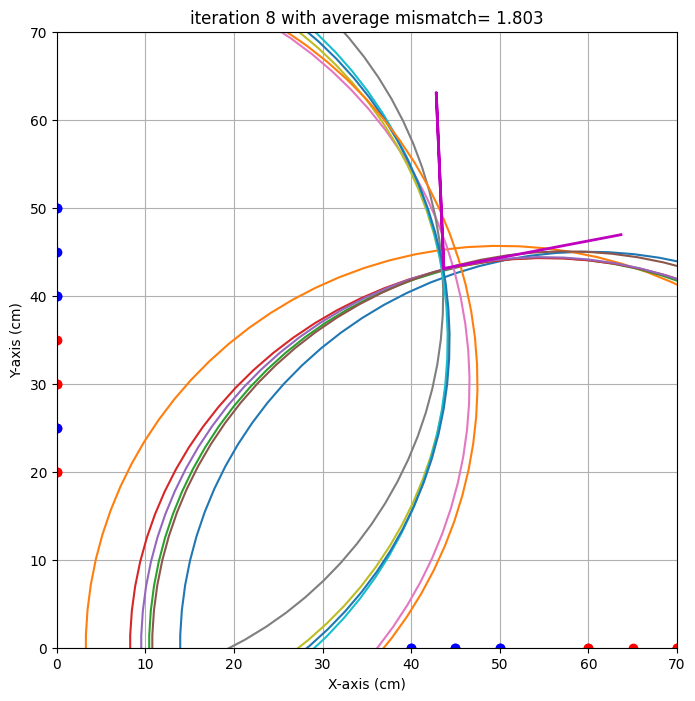

end iteration 8 with average mismatch= 1.803


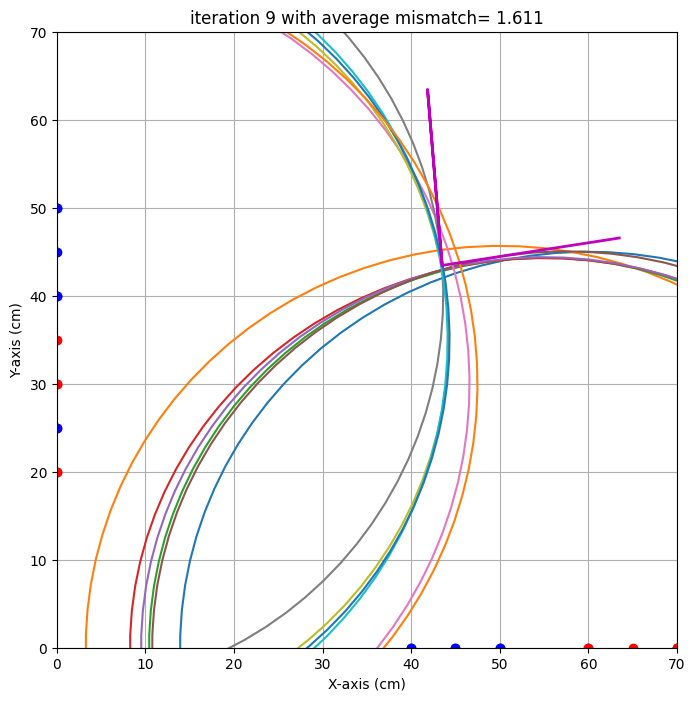

end iteration 9 with average mismatch= 1.611


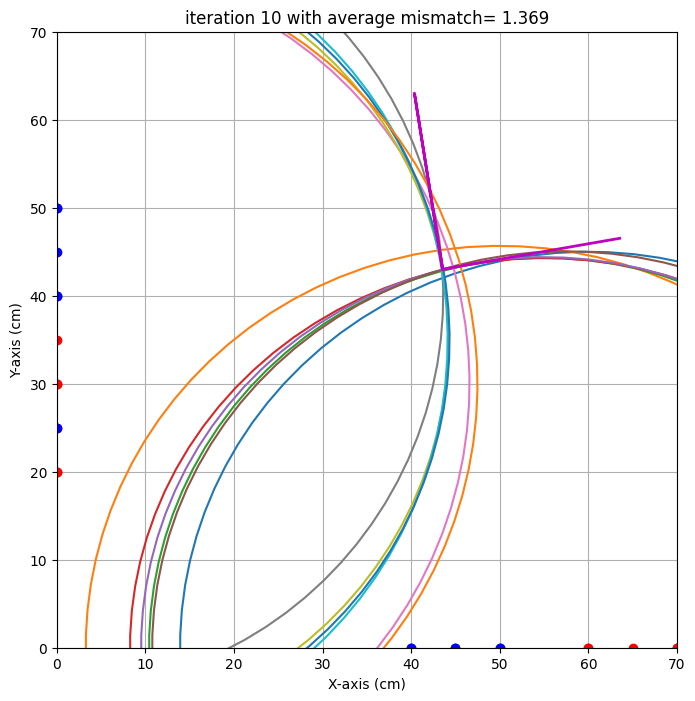

end iteration 10 with average mismatch= 1.369
end iteration 11 with average mismatch= 1.369
end iteration 12 with average mismatch= 1.267
end iteration 13 with average mismatch= 1.236
end iteration 14 with average mismatch= 1.219
end iteration 15 with average mismatch= 1.218
end iteration 16 with average mismatch= 1.207


In [ ]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0': 43 ,
                    'y0': 43.9 ,
                    'alpha' : 7 ,
                    'beta' : -17 
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                    [70,0,50,0,92.2],
                    [60,0,40,0,93.5],
                    [60,0,50,0,89.2],
                    [70,0,40,0,93.5],
                    [65,0,45,0,91.0],
                    [70,0,45,0,93.5],
                    #[0,70,0,50,200],
                    [0,20,0,40,95.3],
                    [0,30,0,50,89.5],
                    [0,30,0,40,89.0],
                    [0,20,0,50,93.2],
                    [0,25,0,45,90.9],
                    [0,35,0,25,95.5],
                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 11: Leerdoelen.
Figuur: ![Alt](tudelftLogo.png "Title")

Figuur: ![Alt](tudelftLogo.png "Title")

Figuur: ![Alt](tudelftLogo.png "Title")